# Bias Analysis: Does the UN Discriminate in Humanitarian Funding?

**Question:** Are CERF + CBPF pooled-fund allocations proportional to documented humanitarian need, or do systematic biases favour certain crises over others?

We test seven bias dimensions:
1. **Geographic** — does region predict underfunding, independent of need?
2. **Crisis type** — are conflict crises treated differently from natural disasters?
3. **Severity alignment** — is funding actually correlated with INFORM severity?
4. **Scale effect** — do larger crises attract disproportionately more/less funding?
5. **Structural neglect** — which countries are *chronically* overlooked across years?
6. **Sector/cluster** — which humanitarian sectors are systematically under-resourced?
7. **Donor geography** — do top donors concentrate their money in specific regions?

Data: OCHA FTS · CERF · CBPF · INFORM (2020–2025)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path(__file__).parent

DATA = PROJECT_ROOT / "data"

# ── Colour palette ─────────────────────────────────────────────────────────
PALETTE = {
    'Africa': '#e74c3c',
    'Middle east': '#e67e22',
    'Asia': '#3498db',
    'Americas': '#2ecc71',
    'Europe': '#9b59b6',
    'Pacific': '#1abc9c',
}
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load core datasets ────────────────────────────────────────────────────
gap = pd.read_csv(DATA / 'country_year_severity_funding.csv')
gap.columns = gap.columns.str.strip()
gap['Year'] = gap['Year'].astype(int)
gap['Pct_Funded'] = pd.to_numeric(gap['Pct_Funded'], errors='coerce').fillna(0)
gap['INFORM Severity Index'] = pd.to_numeric(gap['INFORM Severity Index'], errors='coerce')
gap['revisedRequirements'] = pd.to_numeric(gap['revisedRequirements'], errors='coerce')

sev = pd.read_csv(DATA / 'inform_severity_cleaned.csv')
sev.columns = sev.columns.str.strip()

cerf = pd.read_csv(DATA / 'Data_ CERF Donor Contributions and Allocations - allocations.csv')
cerf.columns = cerf.columns.str.strip()

cluster = pd.read_csv(DATA / 'fts_requirements_funding_cluster_global.csv')
cluster.columns = cluster.columns.str.strip()

fts_in = pd.read_csv(DATA / 'fts_incoming_funding_global.csv')
fts_in.columns = fts_in.columns.str.strip()

# ── Simplify region from severity dataset (take first region token) ───────
sev['region'] = sev['Regions'].str.split(',').str[0].str.strip()
sev_latest = (
    sev.sort_values('Year', ascending=False)
       .drop_duplicates(subset=['ISO3', 'Year'])
)

# ── Merge gap + severity for region / crisis-type / drivers ───────────────
sev_join = sev_latest[['ISO3', 'Year', 'TYPE OF CRISIS', 'region', 'DRIVERS']].copy()
sev_join = sev_join.rename(columns={'ISO3': 'Country_ISO3'})
df = gap.merge(sev_join, on=['Country_ISO3', 'Year'], how='left')

# ── Coverage ratio (0–1) ──────────────────────────────────────────────────
df['coverage'] = (df['Pct_Funded'] / 100).clip(0, 1)
df['log_req'] = np.log1p(df['revisedRequirements'])

print(f'Master dataset: {len(df)} rows, {df["Country_ISO3"].nunique()} countries, {df["Year"].nunique()} years')
df.head(3)

Master dataset: 346 rows, 71 countries, 6 years


,Country_ISO3,Year,revisedRequirements,INFORM Severity Index,Plan_Count,CERF_Funding,CBPF_Budget,Total_Actual_Funding,Funding_Gap,Pct_Funded,TYPE OF CRISIS,region,DRIVERS,coverage,log_req
0,SYR,2020,4617532832,4.9,4,54883071.0,68737943.05,1.236210e+08,4.493912e+09,2.68,Complex crisis,Middle east,NaN,0.0268,22.253126
1,AFG,2020,1931050820,4.6,4,27999965.0,74274515.41,1.022745e+08,1.828776e+09,5.30,Complex crisis,Asia,NaN,0.0530,21.381330
2,YEM,2020,8452043406,4.6,5,64999937.0,99093834.22,1.640938e+08,8.287950e+09,1.94,Complex crisis,Middle east,NaN,0.0194,22.857674


---
## 1. Geographic Bias — Does Region Predict Underfunding?

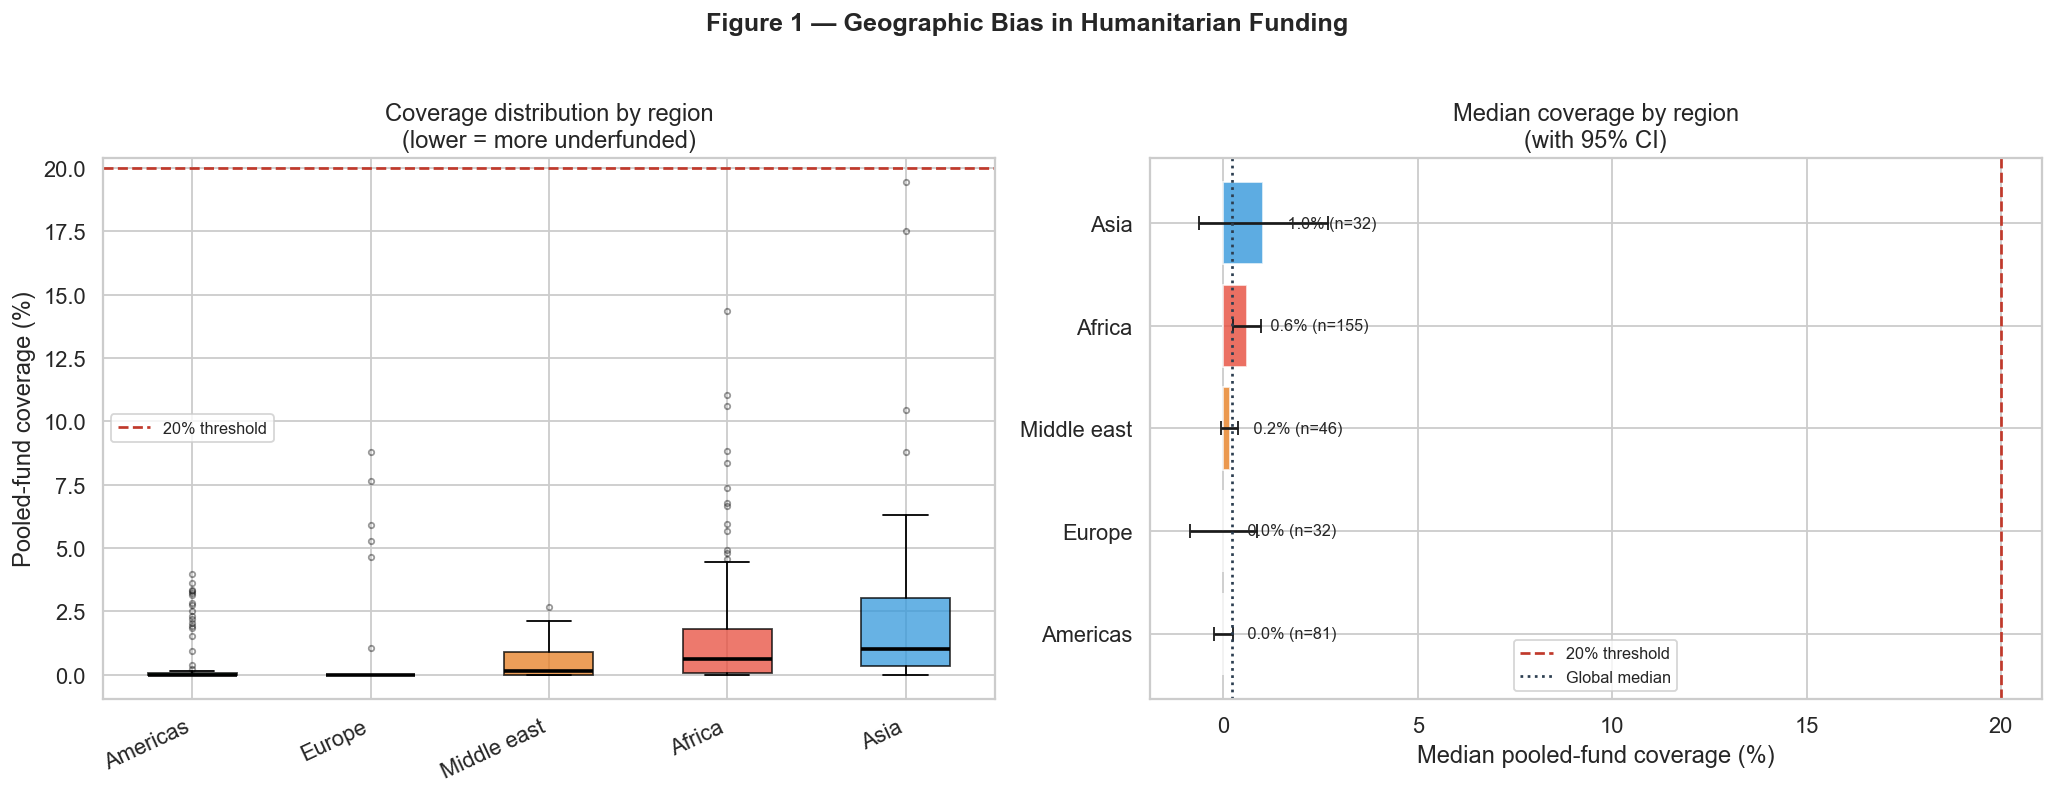


Kruskal-Wallis test across regions: H=61.11, p=0.0000
→ SIGNIFICANT difference across regions


In [3]:
# ── Average coverage by region ────────────────────────────────────────────
region_stats = (
    df.dropna(subset=['region'])
      .groupby('region')['coverage']
      .agg(['mean', 'median', 'std', 'count'])
      .rename(columns={'mean': 'avg_cov', 'median': 'med_cov', 'std': 'std_cov', 'count': 'n'})
      .sort_values('med_cov')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: box plots by region
ax = axes[0]
order = region_stats['region'].tolist()
data_plot = df.dropna(subset=['region'])
colors = [PALETTE.get(r, '#95a5a6') for r in order]
bp = ax.boxplot(
    [data_plot[data_plot['region'] == r]['coverage'].values * 100 for r in order],
    labels=order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.axhline(20, color='#c0392b', lw=1.5, ls='--', label='20% threshold')
ax.set_ylabel('Pooled-fund coverage (%)')
ax.set_title('Coverage distribution by region\n(lower = more underfunded)')
ax.set_xticklabels(order, rotation=25, ha='right')
ax.legend(fontsize=9)

# Right: median + CI bar chart
ax2 = axes[1]
ci95 = 1.96 * region_stats['std_cov'] / np.sqrt(region_stats['n'])
bars = ax2.barh(
    region_stats['region'],
    region_stats['med_cov'] * 100,
    xerr=ci95 * 100,
    color=[PALETTE.get(r, '#95a5a6') for r in region_stats['region']],
    alpha=0.8, capsize=4
)
ax2.axvline(20, color='#c0392b', lw=1.5, ls='--', label='20% threshold')
ax2.axvline(df['coverage'].median() * 100, color='#2c3e50', lw=1.5, ls=':', label='Global median')
for i, (val, n) in enumerate(zip(region_stats['med_cov'] * 100, region_stats['n'])):
    ax2.text(val + 0.5, i, f' {val:.1f}% (n={n})', va='center', fontsize=9)
ax2.set_xlabel('Median pooled-fund coverage (%)')
ax2.set_title('Median coverage by region\n(with 95% CI)')
ax2.legend(fontsize=9)

plt.suptitle('Figure 1 — Geographic Bias in Humanitarian Funding', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Kruskal-Wallis test
groups = [data_plot[data_plot['region'] == r]['coverage'].dropna().values for r in order if len(data_plot[data_plot['region'] == r]) >= 5]
h_stat, p_val = stats.kruskal(*groups)
print(f'\nKruskal-Wallis test across regions: H={h_stat:.2f}, p={p_val:.4f}')
print('→', 'SIGNIFICANT difference across regions' if p_val < 0.05 else 'No significant difference')

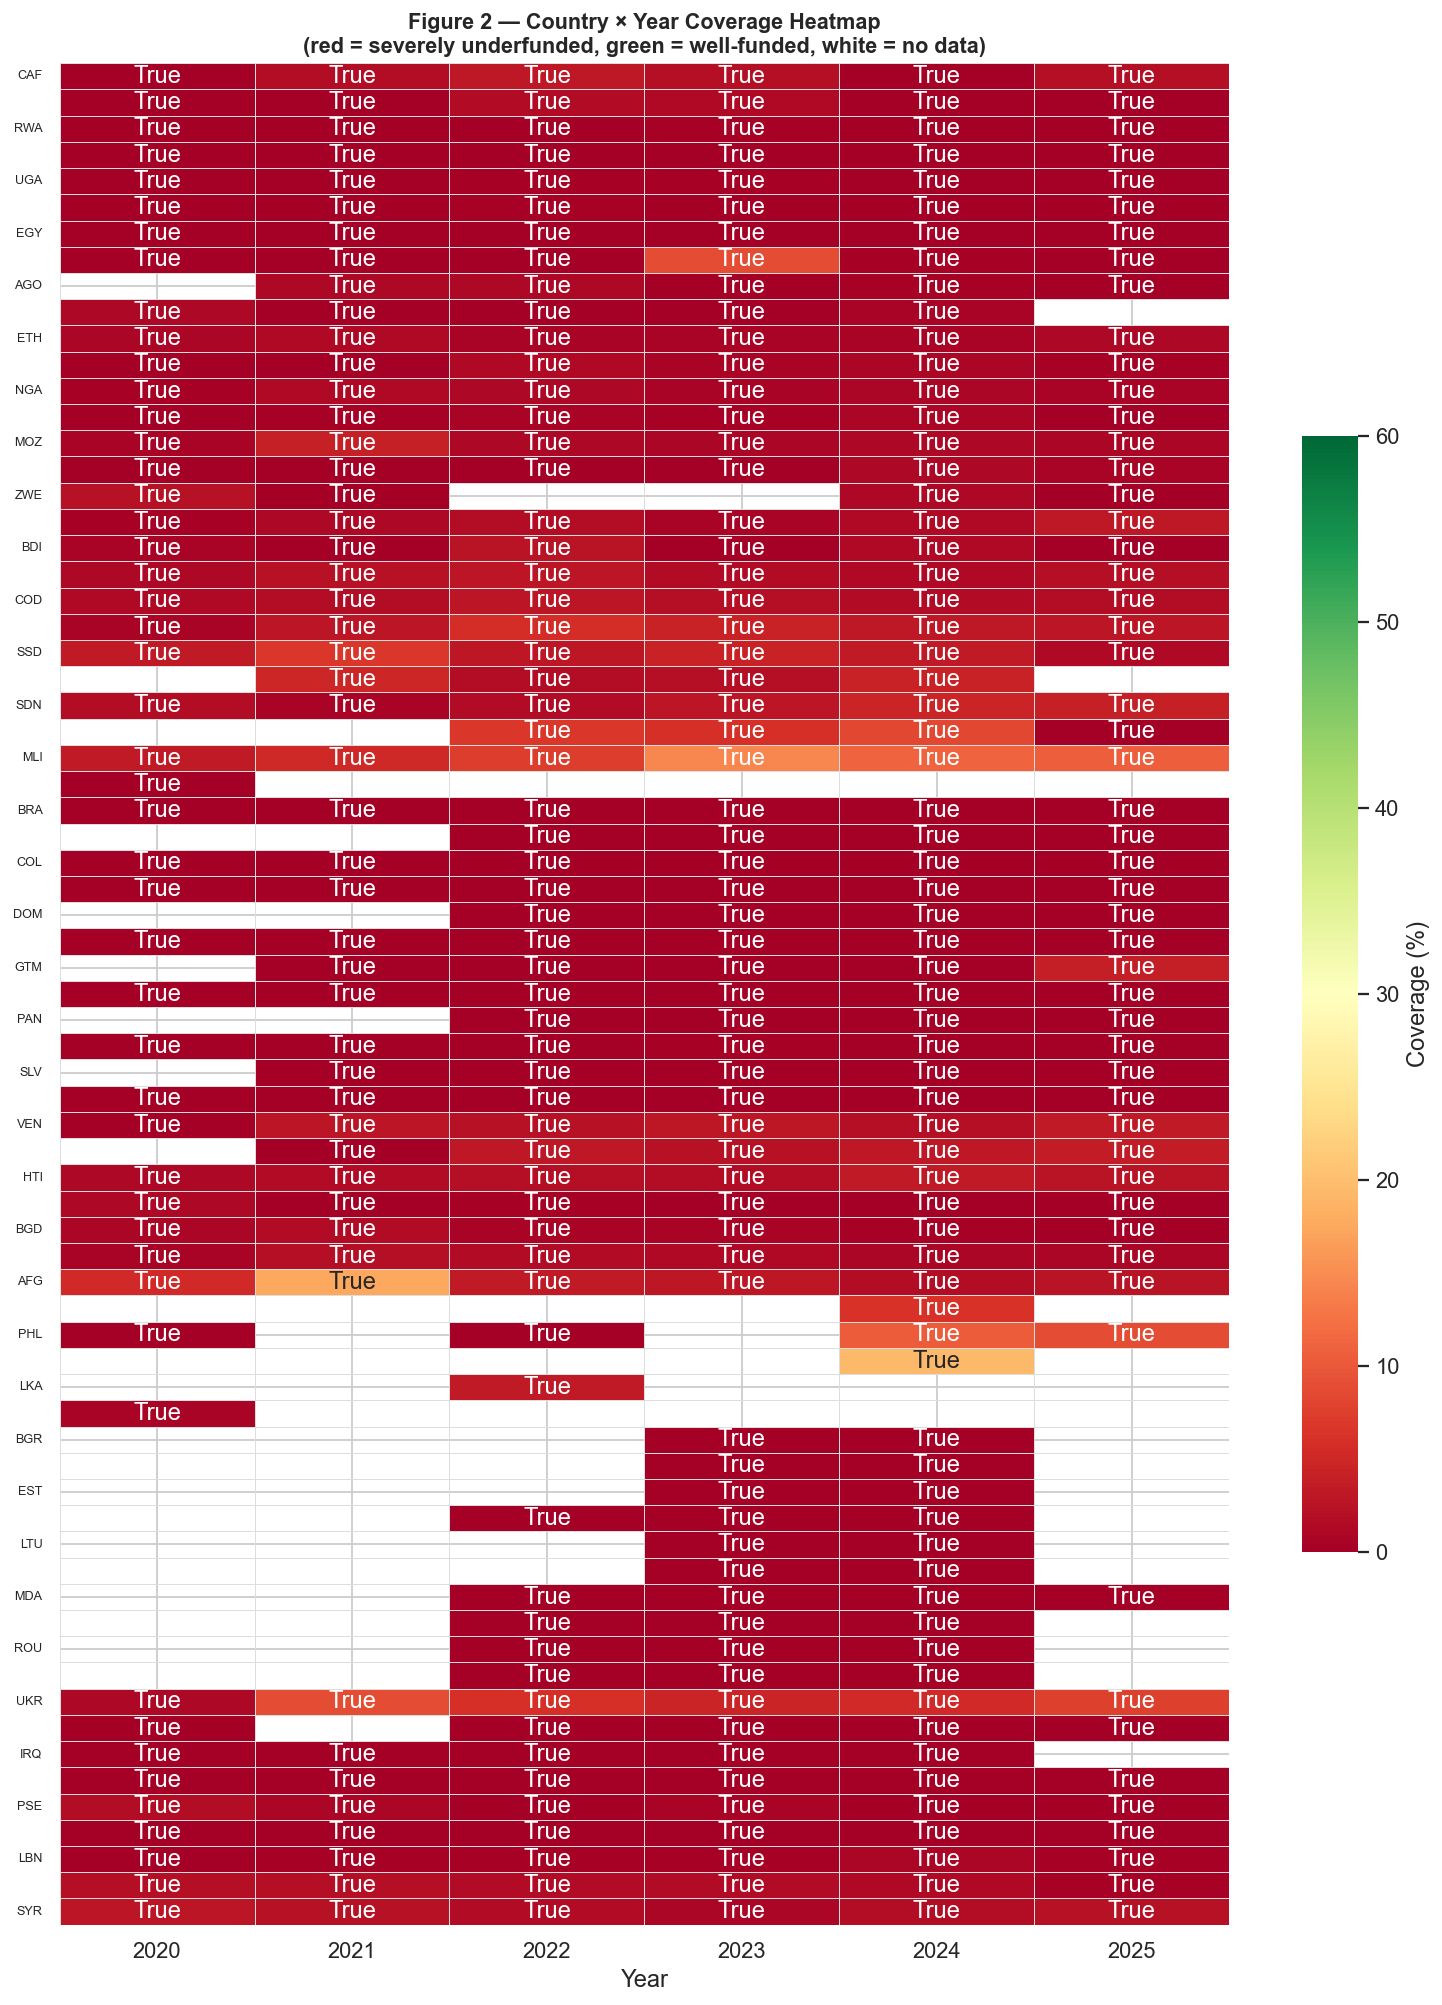

In [4]:
# ── Coverage heatmap: country × year (only countries in data) ─────────────
pivot = df.pivot_table(index='Country_ISO3', columns='Year', values='coverage', aggfunc='mean')
pivot = pivot * 100

# Add region for row sorting
iso_region = df[['Country_ISO3', 'region']].dropna().drop_duplicates().set_index('Country_ISO3')['region']
pivot['_region'] = pivot.index.map(iso_region)
pivot = pivot.sort_values(['_region', 2024], ascending=[True, True])
pivot_clean = pivot.drop(columns='_region')

fig, ax = plt.subplots(figsize=(12, max(10, len(pivot_clean) * 0.22)))
sns.heatmap(
    pivot_clean,
    cmap='RdYlGn', vmin=0, vmax=60,
    linewidths=0.3, linecolor='#ddd',
    ax=ax,
    cbar_kws={'label': 'Coverage (%)', 'shrink': 0.6},
    annot=pivot_clean.notna(),  # just highlights, no numbers
    fmt='',
)
ax.set_title('Figure 2 — Country × Year Coverage Heatmap\n(red = severely underfunded, green = well-funded, white = no data)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

---
## 2. Crisis-Type Bias — Are Conflicts Treated Differently from Disasters?

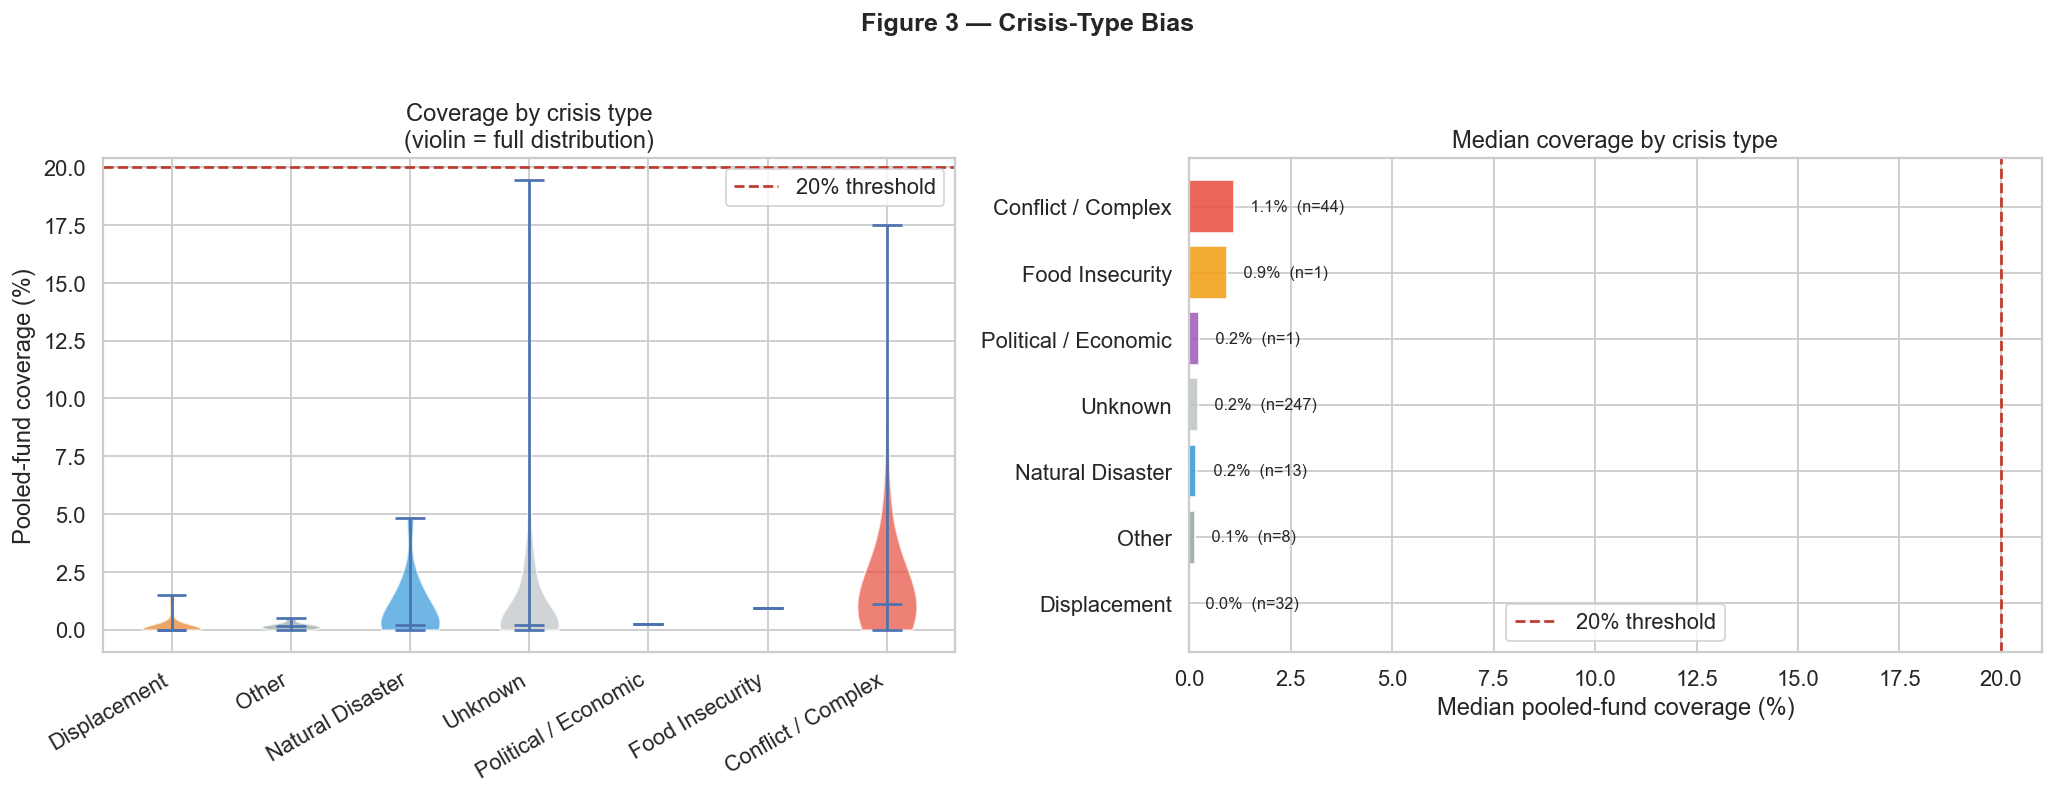


Summary table:
        crisis_group     med      avg   n
        Displacement 0.00000 0.001791  32
               Other 0.00140 0.001550   8
    Natural Disaster 0.00180 0.009023  13
             Unknown 0.00210 0.012921 247
Political / Economic 0.00240 0.002400   1
     Food Insecurity 0.00940 0.009400   1
  Conflict / Complex 0.01105 0.020532  44


In [5]:
# Aggregate crisis type groups
def classify_crisis(t):
    if pd.isna(t): return 'Unknown'
    t = str(t).lower()
    if 'conflict' in t or 'violence' in t or 'complex' in t: return 'Conflict / Complex'
    if 'displace' in t: return 'Displacement'
    if 'drought' in t or 'flood' in t or 'cyclone' in t or 'earthquake' in t: return 'Natural Disaster'
    if 'food' in t: return 'Food Insecurity'
    if 'political' in t or 'economic' in t: return 'Political / Economic'
    return 'Other'

df['crisis_group'] = df['TYPE OF CRISIS'].apply(classify_crisis)

ct_stats = (
    df.groupby('crisis_group')['coverage']
      .agg(['median', 'mean', 'count'])
      .rename(columns={'median': 'med', 'mean': 'avg', 'count': 'n'})
      .sort_values('med')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot
ax = axes[0]
crisis_colors = {
    'Conflict / Complex': '#e74c3c',
    'Displacement': '#e67e22',
    'Natural Disaster': '#3498db',
    'Food Insecurity': '#f39c12',
    'Political / Economic': '#9b59b6',
    'Other': '#95a5a6',
    'Unknown': '#bdc3c7',
}
parts = ax.violinplot(
    [df[df['crisis_group'] == g]['coverage'].dropna().values * 100 
     for g in ct_stats['crisis_group']],
    positions=range(len(ct_stats)),
    showmedians=True
)
for i, (body, g) in enumerate(zip(parts['bodies'], ct_stats['crisis_group'])):
    body.set_facecolor(crisis_colors.get(g, '#95a5a6'))
    body.set_alpha(0.7)
ax.axhline(20, color='#c0392b', lw=1.5, ls='--', label='20% threshold')
ax.set_xticks(range(len(ct_stats)))
ax.set_xticklabels(ct_stats['crisis_group'], rotation=30, ha='right')
ax.set_ylabel('Pooled-fund coverage (%)')
ax.set_title('Coverage by crisis type\n(violin = full distribution)')
ax.legend()

# Median + sample size
ax2 = axes[1]
bars = ax2.barh(
    ct_stats['crisis_group'],
    ct_stats['med'] * 100,
    color=[crisis_colors.get(g, '#95a5a6') for g in ct_stats['crisis_group']],
    alpha=0.85
)
ax2.axvline(20, color='#c0392b', lw=1.5, ls='--', label='20% threshold')
for i, (val, n) in enumerate(zip(ct_stats['med'] * 100, ct_stats['n'])):
    ax2.text(val + 0.3, i, f' {val:.1f}%  (n={n})', va='center', fontsize=9)
ax2.set_xlabel('Median pooled-fund coverage (%)')
ax2.set_title('Median coverage by crisis type')
ax2.legend()

plt.suptitle('Figure 3 — Crisis-Type Bias', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nSummary table:')
print(ct_stats.to_string(index=False))

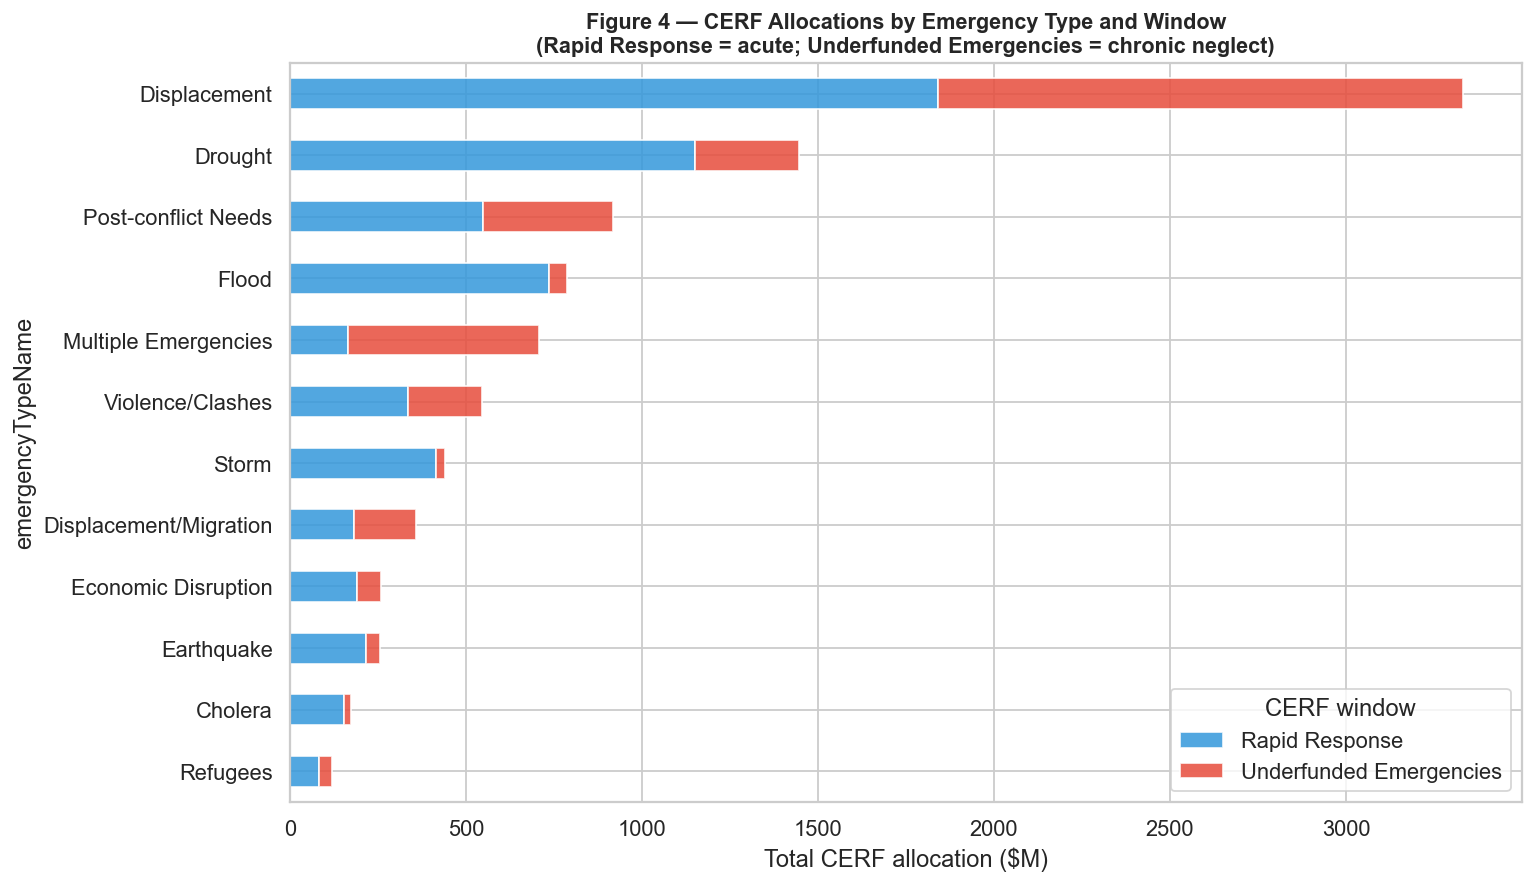

In [6]:
# CERF window analysis: Rapid Response vs. Underfunded Emergencies by emergency type
cerf['totalAmountApproved'] = pd.to_numeric(cerf['totalAmountApproved'], errors='coerce')
cerf_window = (
    cerf.groupby(['emergencyTypeName', 'windowFullName'])['totalAmountApproved']
        .sum().reset_index()
)

# Get top-15 emergency types by total amount
top_emerg = cerf.groupby('emergencyTypeName')['totalAmountApproved'].sum().nlargest(12).index
cerf_w = cerf_window[cerf_window['emergencyTypeName'].isin(top_emerg)]
cerf_pivot = cerf_w.pivot(index='emergencyTypeName', columns='windowFullName', values='totalAmountApproved').fillna(0)
cerf_pivot['total'] = cerf_pivot.sum(axis=1)
cerf_pivot = cerf_pivot.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
cols = [c for c in cerf_pivot.columns if c != 'total']
cerf_pivot[cols].div(1e6).plot(
    kind='barh', stacked=True, ax=ax,
    color=['#3498db', '#e74c3c'],
    alpha=0.85
)
ax.set_xlabel('Total CERF allocation ($M)')
ax.set_title('Figure 4 — CERF Allocations by Emergency Type and Window\n'
             '(Rapid Response = acute; Underfunded Emergencies = chronic neglect)',
             fontsize=12, fontweight='bold')
ax.legend(title='CERF window')
plt.tight_layout()
plt.show()

---
## 3. Severity Alignment — Is Funding Actually Proportional to Need?

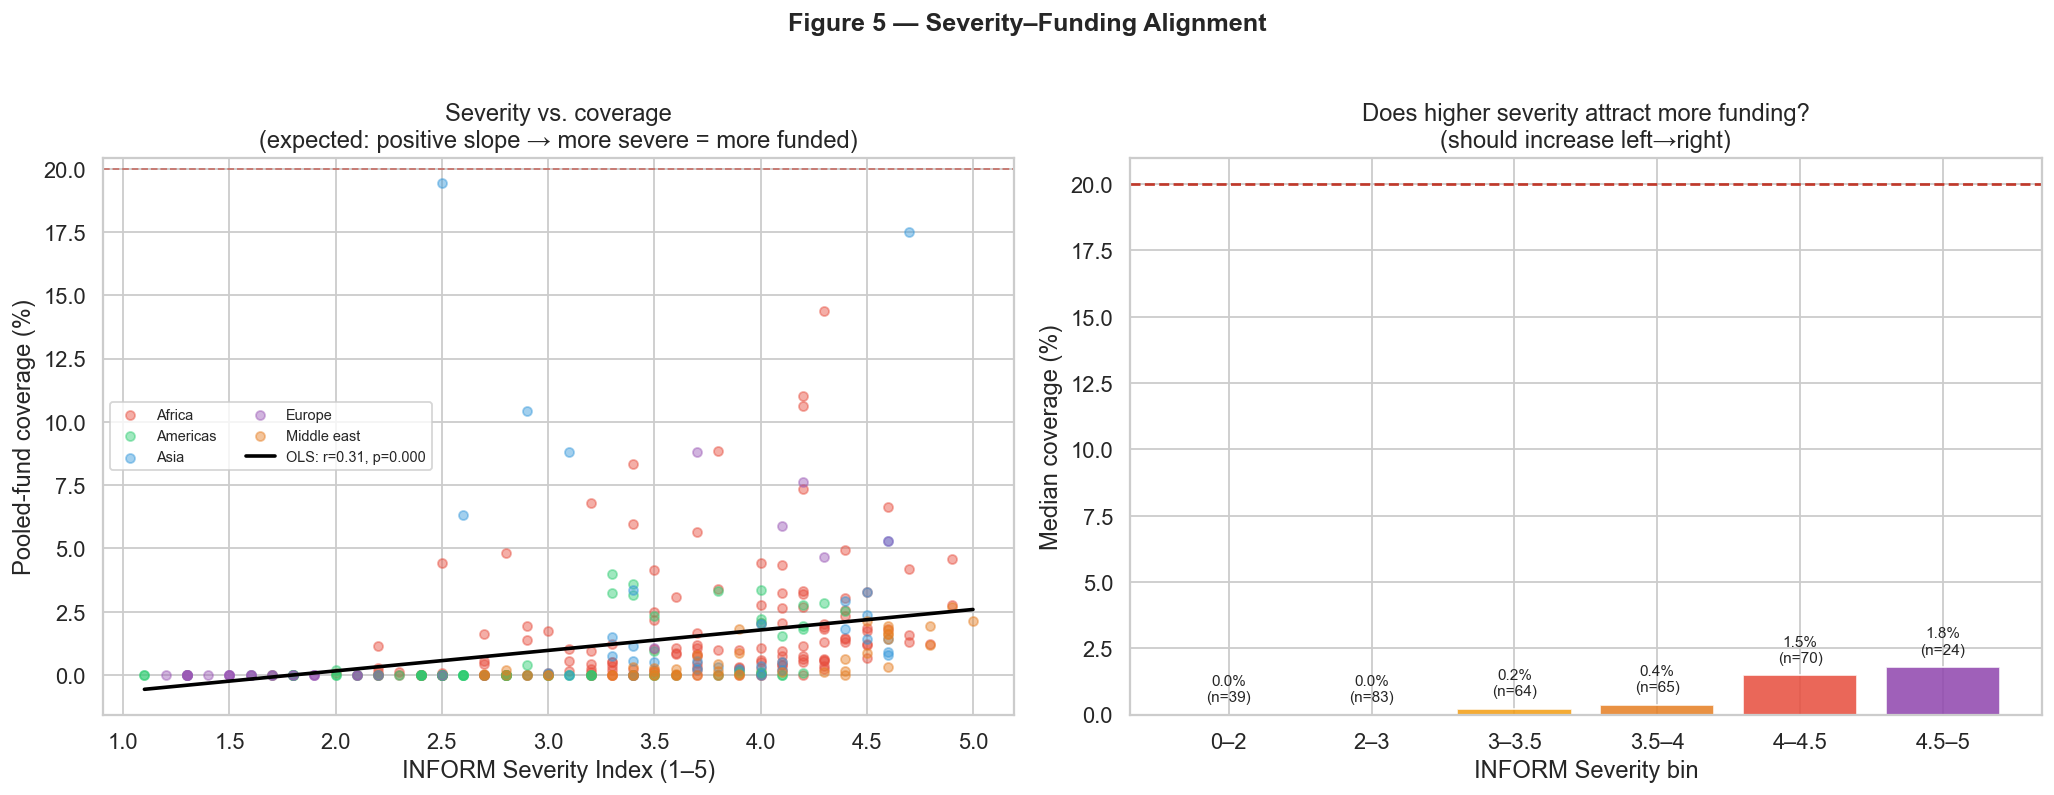

OLS: slope=0.809%/unit severity, R²=0.096, p=0.0000
Interpretation: ✓ Severity predicts MORE funding (aligned)


In [7]:
df_sev = df.dropna(subset=['INFORM Severity Index', 'coverage', 'region'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: severity vs. coverage, coloured by region
ax = axes[0]
for region, grp in df_sev.groupby('region'):
    ax.scatter(
        grp['INFORM Severity Index'],
        grp['coverage'] * 100,
        alpha=0.45, s=25,
        color=PALETTE.get(region, '#95a5a6'),
        label=region
    )
# Regression line
m, b, r, p, _ = stats.linregress(df_sev['INFORM Severity Index'], df_sev['coverage'] * 100)
x_line = np.linspace(df_sev['INFORM Severity Index'].min(), df_sev['INFORM Severity Index'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', lw=2, label=f'OLS: r={r:.2f}, p={p:.3f}')
ax.axhline(20, color='#c0392b', lw=1, ls='--', alpha=0.6)
ax.set_xlabel('INFORM Severity Index (1–5)')
ax.set_ylabel('Pooled-fund coverage (%)')
ax.set_title('Severity vs. coverage\n(expected: positive slope → more severe = more funded)')
ax.legend(fontsize=8, ncol=2)

# Bin severity and show coverage by bin
ax2 = axes[1]
df_sev = df_sev.copy()
df_sev['sev_bin'] = pd.cut(df_sev['INFORM Severity Index'], bins=[0, 2, 3, 3.5, 4, 4.5, 5.1],
                            labels=['0–2', '2–3', '3–3.5', '3.5–4', '4–4.5', '4.5–5'])
bin_stats = df_sev.groupby('sev_bin', observed=True)['coverage'].agg(['median', 'mean', 'count'])
ax2.bar(range(len(bin_stats)), bin_stats['median'] * 100,
        color=['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad'],
        alpha=0.85)
for i, (val, n) in enumerate(zip(bin_stats['median'] * 100, bin_stats['count'])):
    ax2.text(i, val + 0.5, f'{val:.1f}%\n(n={n})', ha='center', fontsize=8.5)
ax2.set_xticks(range(len(bin_stats)))
ax2.set_xticklabels(bin_stats.index)
ax2.axhline(20, color='#c0392b', lw=1.5, ls='--')
ax2.set_xlabel('INFORM Severity bin')
ax2.set_ylabel('Median coverage (%)')
ax2.set_title('Does higher severity attract more funding?\n(should increase left→right)')

plt.suptitle('Figure 5 — Severity–Funding Alignment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'OLS: slope={m:.3f}%/unit severity, R²={r**2:.3f}, p={p:.4f}')
print('Interpretation:', '✓ Severity predicts MORE funding (aligned)' if (m > 0 and p < 0.05)
      else '⚠️ Severity predicts LESS funding (counter-aligned) — possible bias'
      if (m < 0 and p < 0.05) else '→ No significant relationship')

---
## 4. Scale Effect — Do Massive Crises Crowd Out Smaller Ones?

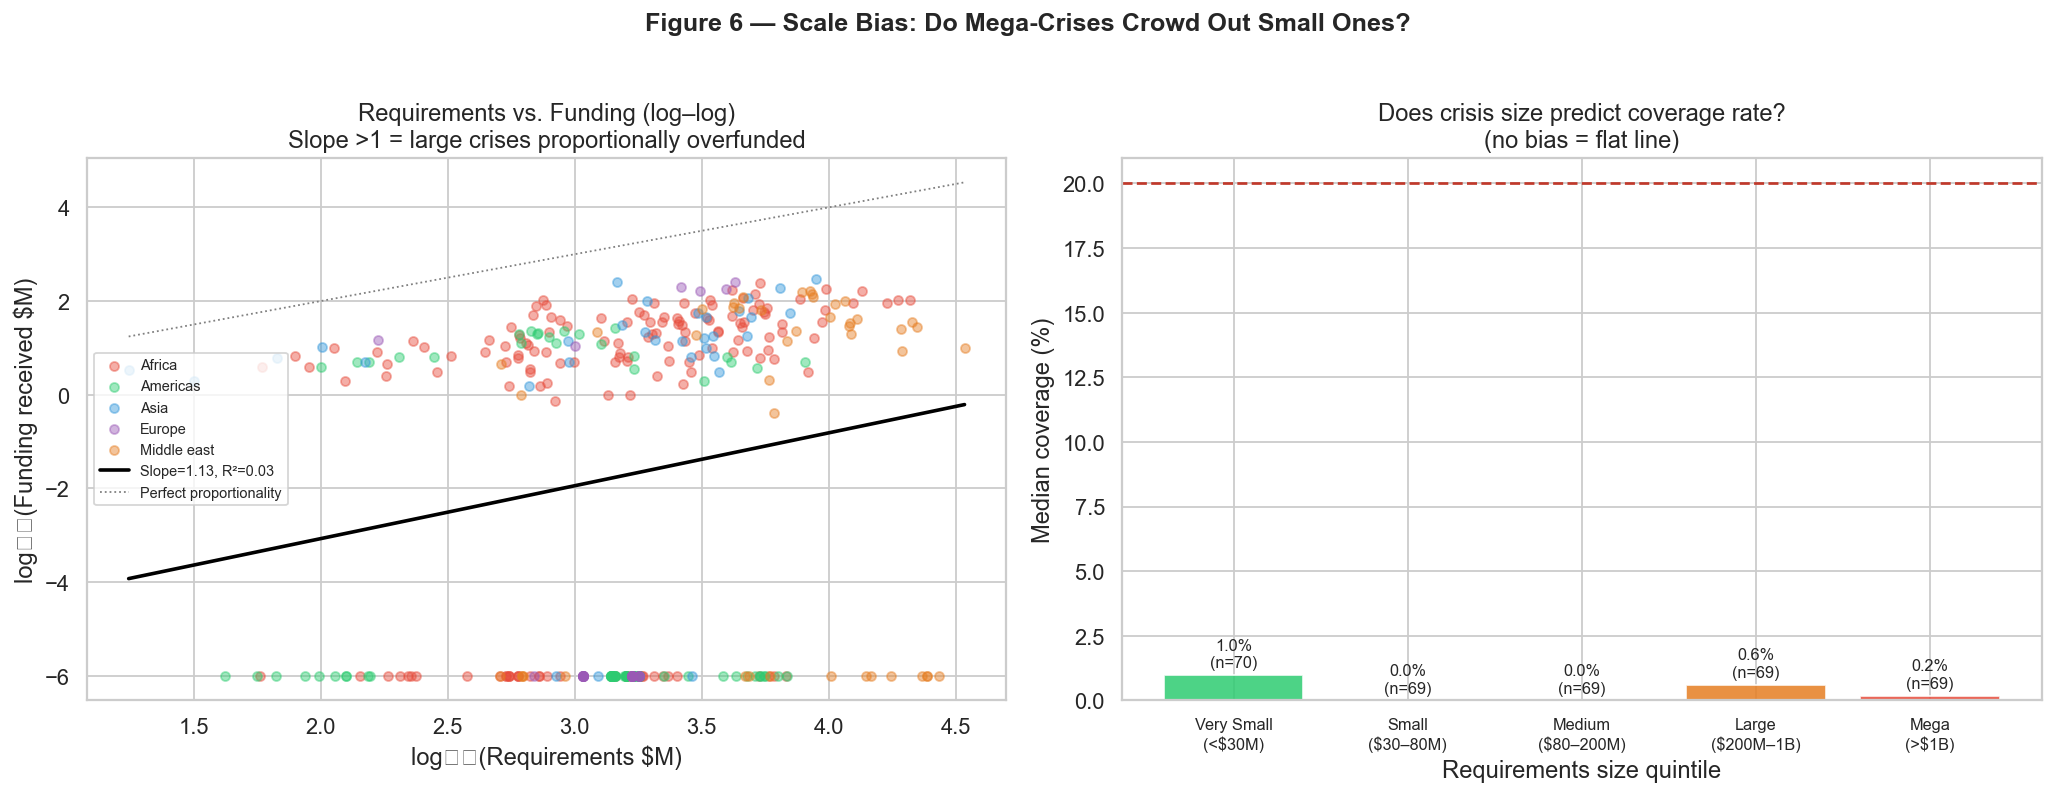

Log-log regression slope = 1.129  (1.0 = perfectly proportional, <1 = diminishing returns for large crises)


In [8]:
df_scale = df.dropna(subset=['revisedRequirements', 'coverage', 'region'])
df_scale = df_scale[df_scale['revisedRequirements'] > 1e6].copy()
df_scale['req_M'] = df_scale['revisedRequirements'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log-log scatter: requirements vs. absolute funding
ax = axes[0]
for region, grp in df_scale.groupby('region'):
    ax.scatter(
        np.log10(grp['req_M']),
        np.log10(grp['Total_Actual_Funding'].clip(1) / 1e6),
        alpha=0.45, s=25,
        color=PALETTE.get(region, '#95a5a6'),
        label=region
    )
x_vals = np.log10(df_scale['req_M'])
y_vals = np.log10(df_scale['Total_Actual_Funding'].clip(1) / 1e6)
m2, b2, r2, p2, _ = stats.linregress(x_vals.dropna(), y_vals[x_vals.notna()])
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, m2 * x_line + b2, color='black', lw=2, label=f'Slope={m2:.2f}, R²={r2**2:.2f}')
ax.plot(x_line, x_line, color='grey', lw=1, ls=':', label='Perfect proportionality')
ax.set_xlabel('log₁₀(Requirements $M)')
ax.set_ylabel('log₁₀(Funding received $M)')
ax.set_title('Requirements vs. Funding (log–log)\nSlope >1 = large crises proportionally overfunded')
ax.legend(fontsize=8)

# Coverage vs. requirements (do bigger crises get funded at a different rate?)
ax2 = axes[1]
req_bins = pd.qcut(df_scale['req_M'], q=5, 
                    labels=['Very Small\n(<$30M)', 'Small\n($30–80M)', 
                            'Medium\n($80–200M)', 'Large\n($200M–1B)', 'Mega\n(>$1B)'])
bin_cov = df_scale.groupby(req_bins, observed=True)['coverage'].agg(['median', 'count'])
bars = ax2.bar(range(len(bin_cov)), bin_cov['median'] * 100,
               color=['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c'], alpha=0.85)
for i, (val, n) in enumerate(zip(bin_cov['median'] * 100, bin_cov['count'])):
    ax2.text(i, val + 0.3, f'{val:.1f}%\n(n={n})', ha='center', fontsize=9)
ax2.set_xticks(range(len(bin_cov)))
ax2.set_xticklabels(bin_cov.index, fontsize=9)
ax2.axhline(20, color='#c0392b', lw=1.5, ls='--')
ax2.set_xlabel('Requirements size quintile')
ax2.set_ylabel('Median coverage (%)')
ax2.set_title('Does crisis size predict coverage rate?\n(no bias = flat line)')

plt.suptitle('Figure 6 — Scale Bias: Do Mega-Crises Crowd Out Small Ones?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Log-log regression slope = {m2:.3f}  (1.0 = perfectly proportional, <1 = diminishing returns for large crises)')

---
## 5. Structural Neglect — Who Has Been Chronically Ignored?

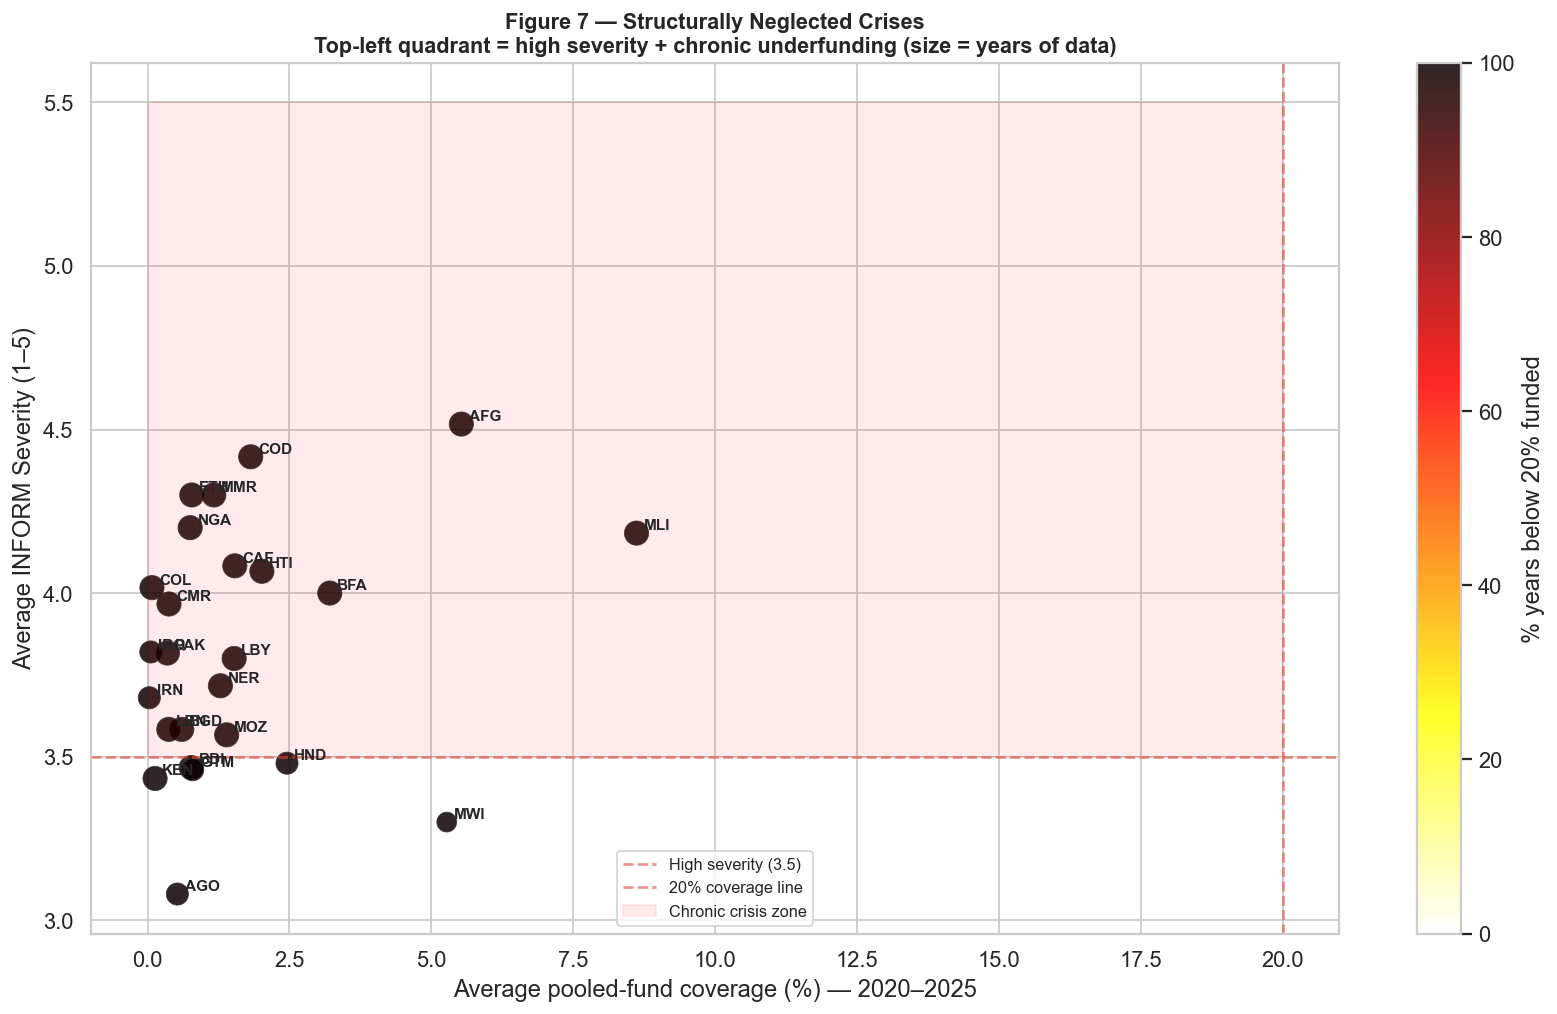

In [9]:
# Count consecutive years below 20% coverage per country (simplified: just total years below 20%)
below20 = df.copy()
below20['below20'] = below20['coverage'] < 0.20
neglect = (
    below20.groupby('Country_ISO3')
           .agg(
               years_total=('Year', 'count'),
               years_below20=('below20', 'sum'),
               avg_coverage=('coverage', 'mean'),
               avg_severity=('INFORM Severity Index', 'mean'),
               region=('region', 'first'),
           )
           .reset_index()
)
neglect['pct_years_below20'] = neglect['years_below20'] / neglect['years_total'] * 100
neglect = neglect[neglect['years_total'] >= 2]  # at least 2 years of data

# Top structurally neglected: high severity + consistently below 20%
top_neglect = neglect[neglect['avg_severity'] >= 3.0].nlargest(25, 'pct_years_below20')

fig, ax = plt.subplots(figsize=(13, 8))
scatter = ax.scatter(
    top_neglect['avg_coverage'] * 100,
    top_neglect['avg_severity'],
    c=top_neglect['pct_years_below20'],
    cmap='hot_r',
    s=top_neglect['years_total'] * 30,
    alpha=0.85, edgecolors='#333', lw=0.5,
    vmin=0, vmax=100
)
plt.colorbar(scatter, ax=ax, label='% years below 20% funded')
for _, row in top_neglect.iterrows():
    ax.annotate(
        row['Country_ISO3'],
        (row['avg_coverage'] * 100, row['avg_severity']),
        xytext=(4, 2), textcoords='offset points',
        fontsize=8.5, fontweight='bold'
    )
ax.axhline(3.5, color='#e74c3c', lw=1.5, ls='--', alpha=0.6, label='High severity (3.5)')
ax.axvline(20, color='#e74c3c', lw=1.5, ls='--', alpha=0.6, label='20% coverage line')
ax.fill_between([0, 20], [3.5, 3.5], [5.5, 5.5], alpha=0.08, color='red', label='Chronic crisis zone')
ax.set_xlabel('Average pooled-fund coverage (%) — 2020–2025')
ax.set_ylabel('Average INFORM Severity (1–5)')
ax.set_title('Figure 7 — Structurally Neglected Crises\n'
             'Top-left quadrant = high severity + chronic underfunding (size = years of data)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

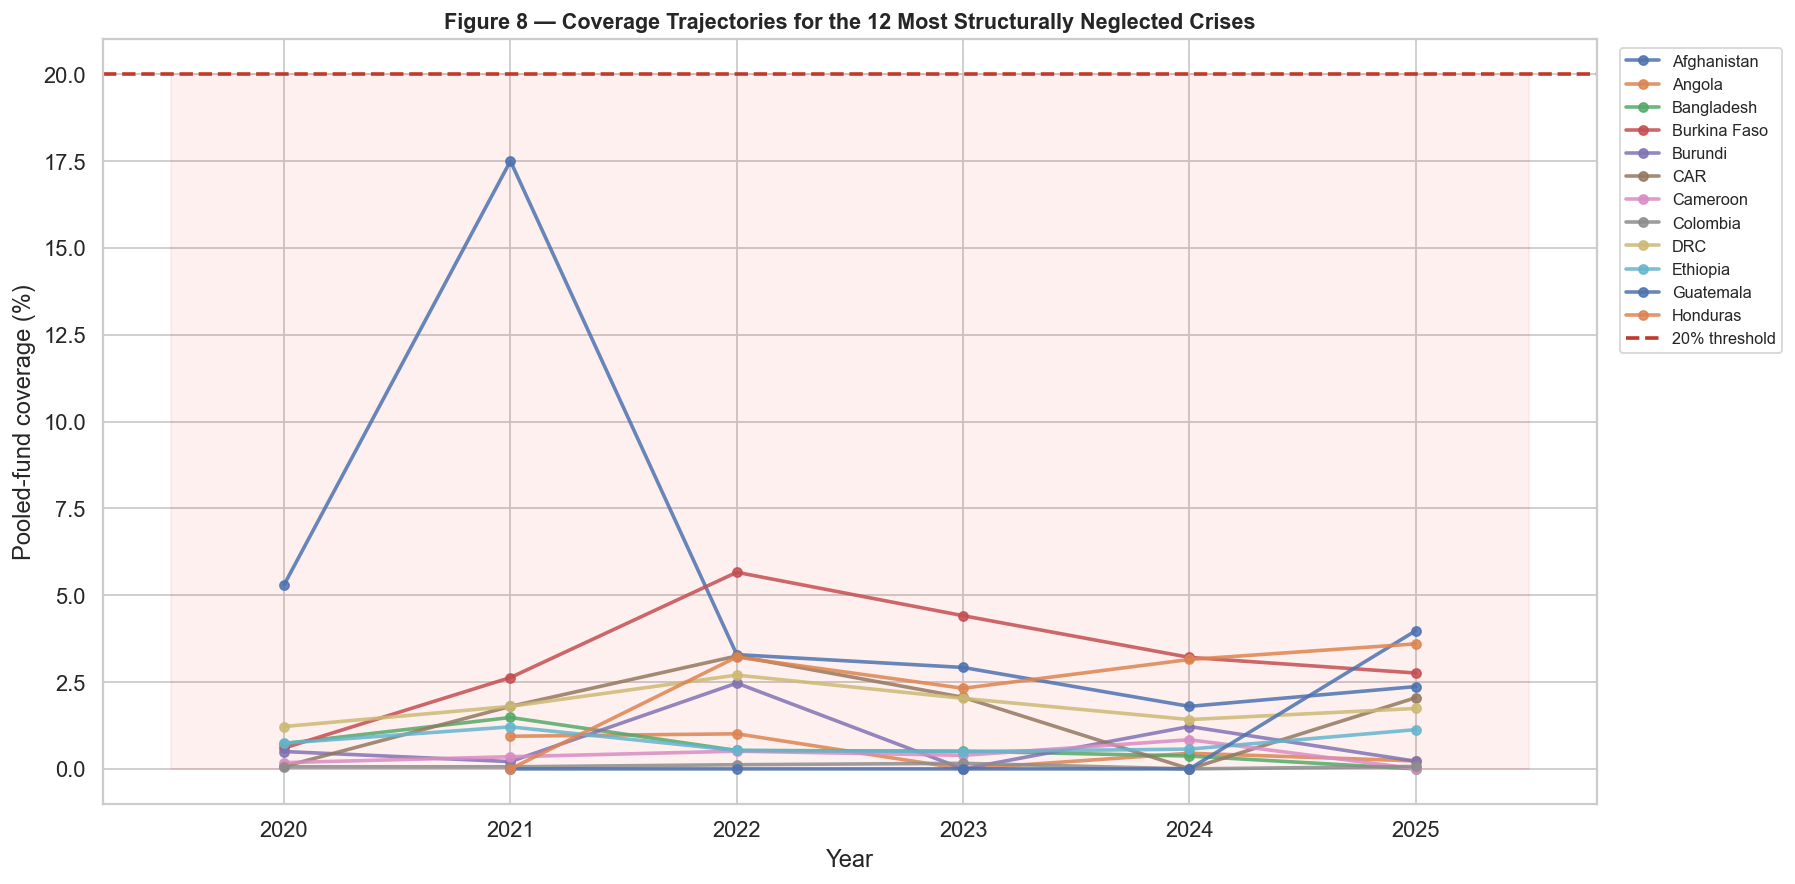

In [10]:
# Multi-year coverage trajectory for the worst 12 neglected countries
worst12 = neglect[neglect['avg_severity'] >= 3.0].nlargest(12, 'pct_years_below20')['Country_ISO3'].tolist()

traj = df[df['Country_ISO3'].isin(worst12)].copy()
# Build a name map
name_map = sev[['ISO3', 'COUNTRY']].dropna().drop_duplicates().set_index('ISO3')['COUNTRY'].to_dict()
traj['label'] = traj['Country_ISO3'].map(name_map).fillna(traj['Country_ISO3'])

fig, ax = plt.subplots(figsize=(14, 7))
for label, grp in traj.groupby('label'):
    grp_sorted = grp.sort_values('Year')
    ax.plot(grp_sorted['Year'], grp_sorted['coverage'] * 100,
            marker='o', lw=2, markersize=5, label=label, alpha=0.85)

ax.axhline(20, color='#c0392b', lw=2, ls='--', label='20% threshold')
ax.fill_between(
    [traj['Year'].min() - 0.5, traj['Year'].max() + 0.5], 
    0, 20, alpha=0.06, color='red'
)
ax.set_xlabel('Year')
ax.set_ylabel('Pooled-fund coverage (%)')
ax.set_title('Figure 8 — Coverage Trajectories for the 12 Most Structurally Neglected Crises',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xticks(sorted(traj['Year'].unique()))
plt.tight_layout()
plt.show()

---
## 6. Sector / Cluster Bias — Which Humanitarian Sectors Are Underfunded?

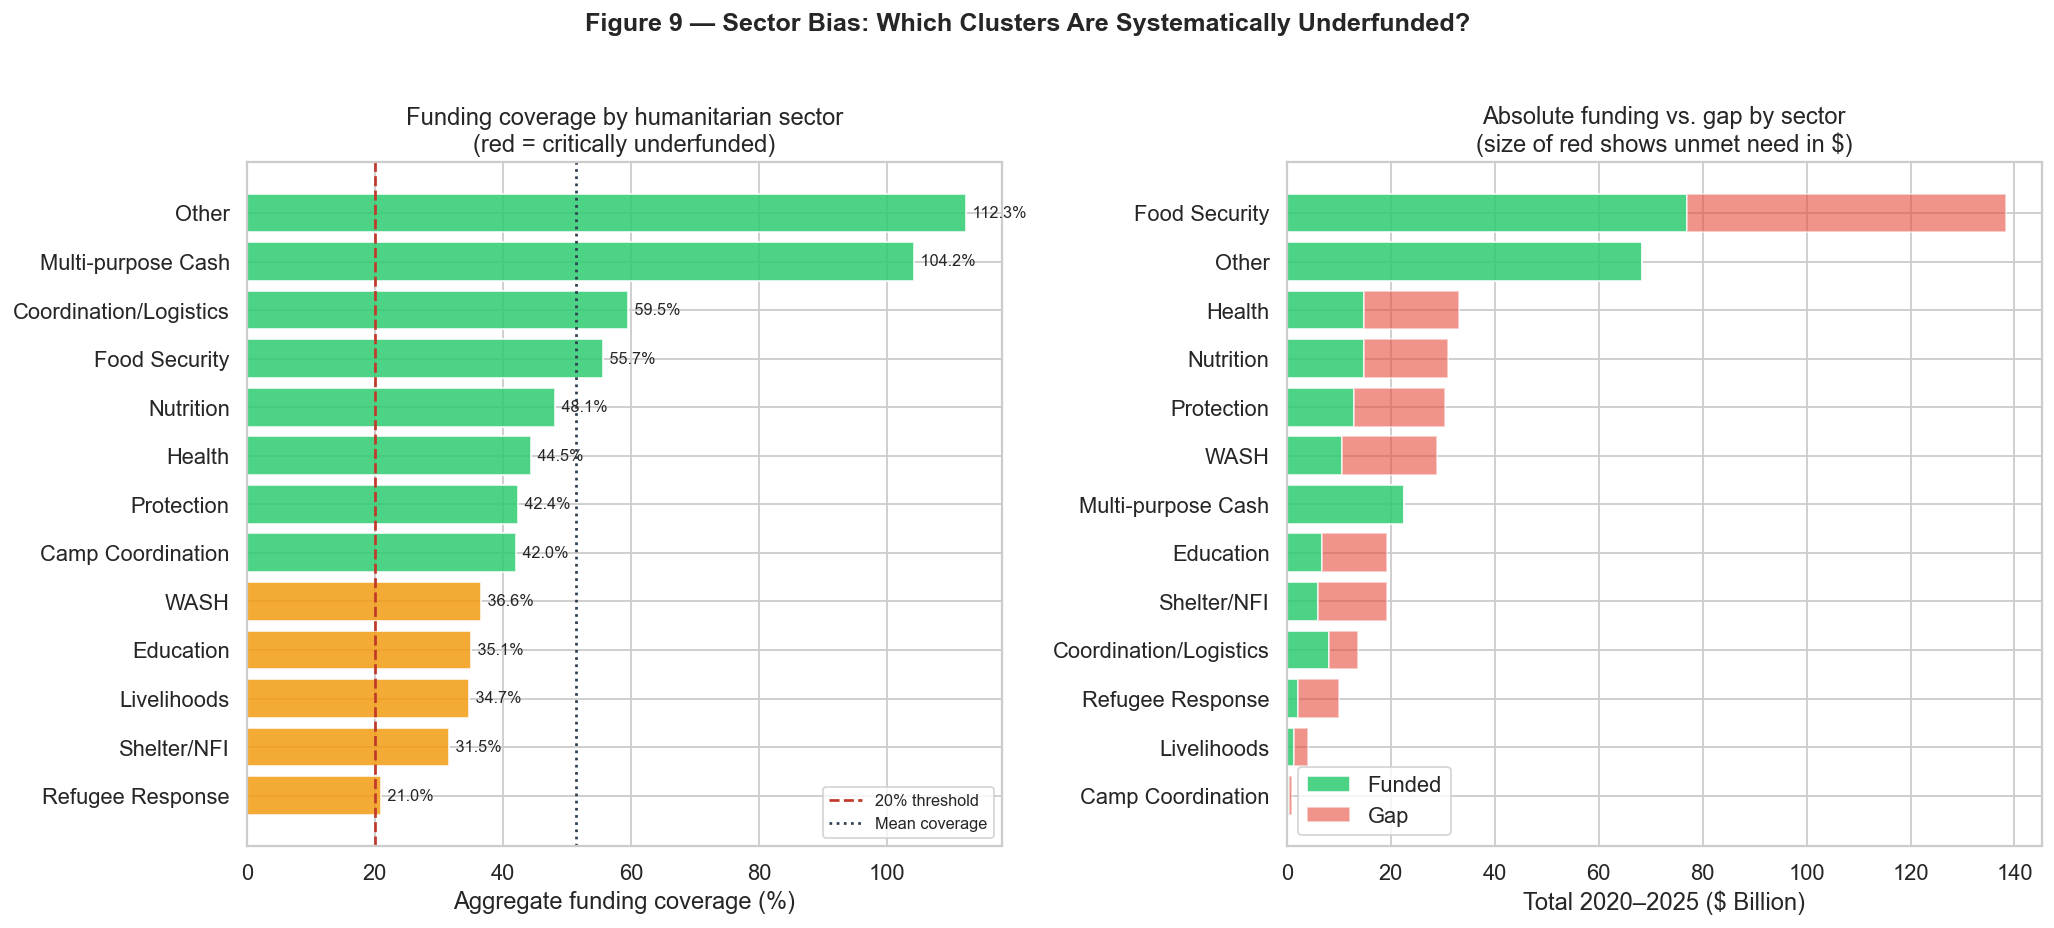

In [11]:
# Clean up duplicate cluster names (multilingual / encoding issues)
cluster['req_n'] = pd.to_numeric(cluster['requirements'], errors='coerce')
cluster['fund_n'] = pd.to_numeric(cluster['funding'], errors='coerce')
cluster['pct_n'] = pd.to_numeric(cluster['percentFunded'], errors='coerce')

# Normalize cluster names — group by canonical English name using keyword matching
def norm_cluster(c):
    if pd.isna(c): return 'Unknown'
    c = str(c).lower()
    if 'food' in c and 'security' in c: return 'Food Security'
    if 'food' in c and not 'security' in c: return 'Food Security'
    if 'nutrition' in c: return 'Nutrition'
    if 'health' in c: return 'Health'
    if 'wash' in c or ('water' in c and 'sanit' in c): return 'WASH'
    if 'shelter' in c or 'nfi' in c: return 'Shelter/NFI'
    if 'education' in c: return 'Education'
    if 'protection' in c: return 'Protection'
    if 'livelihoods' in c or 'livelihood' in c: return 'Livelihoods'
    if 'cash' in c or 'multi' in c: return 'Multi-purpose Cash'
    if 'refugee' in c: return 'Refugee Response'
    if 'logistics' in c or 'emergency telecom' in c or 'coordination' in c: return 'Coordination/Logistics'
    if 'mine' in c or 'cccm' in c or 'camp' in c: return 'Camp Coordination'
    return 'Other'

cluster['cluster_norm'] = cluster['cluster'].apply(norm_cluster)

clust_agg = (
    cluster.groupby('cluster_norm')
           .agg(total_req=('req_n', 'sum'), total_fund=('fund_n', 'sum'), n=('req_n', 'count'))
           .reset_index()
)
clust_agg['coverage'] = clust_agg['total_fund'] / clust_agg['total_req'].clip(lower=1)
clust_agg = clust_agg.sort_values('coverage')
clust_agg = clust_agg[clust_agg['cluster_norm'] != 'Unknown']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: funding coverage by cluster
ax = axes[0]
coverage_vals = clust_agg['coverage'] * 100
bar_colors = ['#e74c3c' if v < 20 else '#f39c12' if v < 40 else '#2ecc71' for v in coverage_vals]
ax.barh(clust_agg['cluster_norm'], coverage_vals, color=bar_colors, alpha=0.85)
ax.axvline(20, color='#c0392b', lw=1.5, ls='--', label='20% threshold')
ax.axvline(clust_agg['coverage'].mean() * 100, color='#2c3e50', lw=1.5, ls=':', label='Mean coverage')
for i, val in enumerate(coverage_vals):
    ax.text(val + 0.3, i, f' {val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Aggregate funding coverage (%)')
ax.set_title('Funding coverage by humanitarian sector\n(red = critically underfunded)')
ax.legend(fontsize=9)

# Right: absolute gap (stacked bar funded vs. gap)
ax2 = axes[1]
clust_plot = clust_agg.sort_values('total_req', ascending=True)
funded_B = clust_plot['total_fund'] / 1e9
gap_B = (clust_plot['total_req'] - clust_plot['total_fund']).clip(lower=0) / 1e9
ax2.barh(clust_plot['cluster_norm'], funded_B, color='#2ecc71', alpha=0.85, label='Funded')
ax2.barh(clust_plot['cluster_norm'], gap_B, left=funded_B, color='#e74c3c', alpha=0.6, label='Gap')
ax2.set_xlabel('Total 2020–2025 ($ Billion)')
ax2.set_title('Absolute funding vs. gap by sector\n(size of red shows unmet need in $)')
ax2.legend()

plt.suptitle('Figure 9 — Sector Bias: Which Clusters Are Systematically Underfunded?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Donor Geography — Do Major Donors Favour Specific Regions?

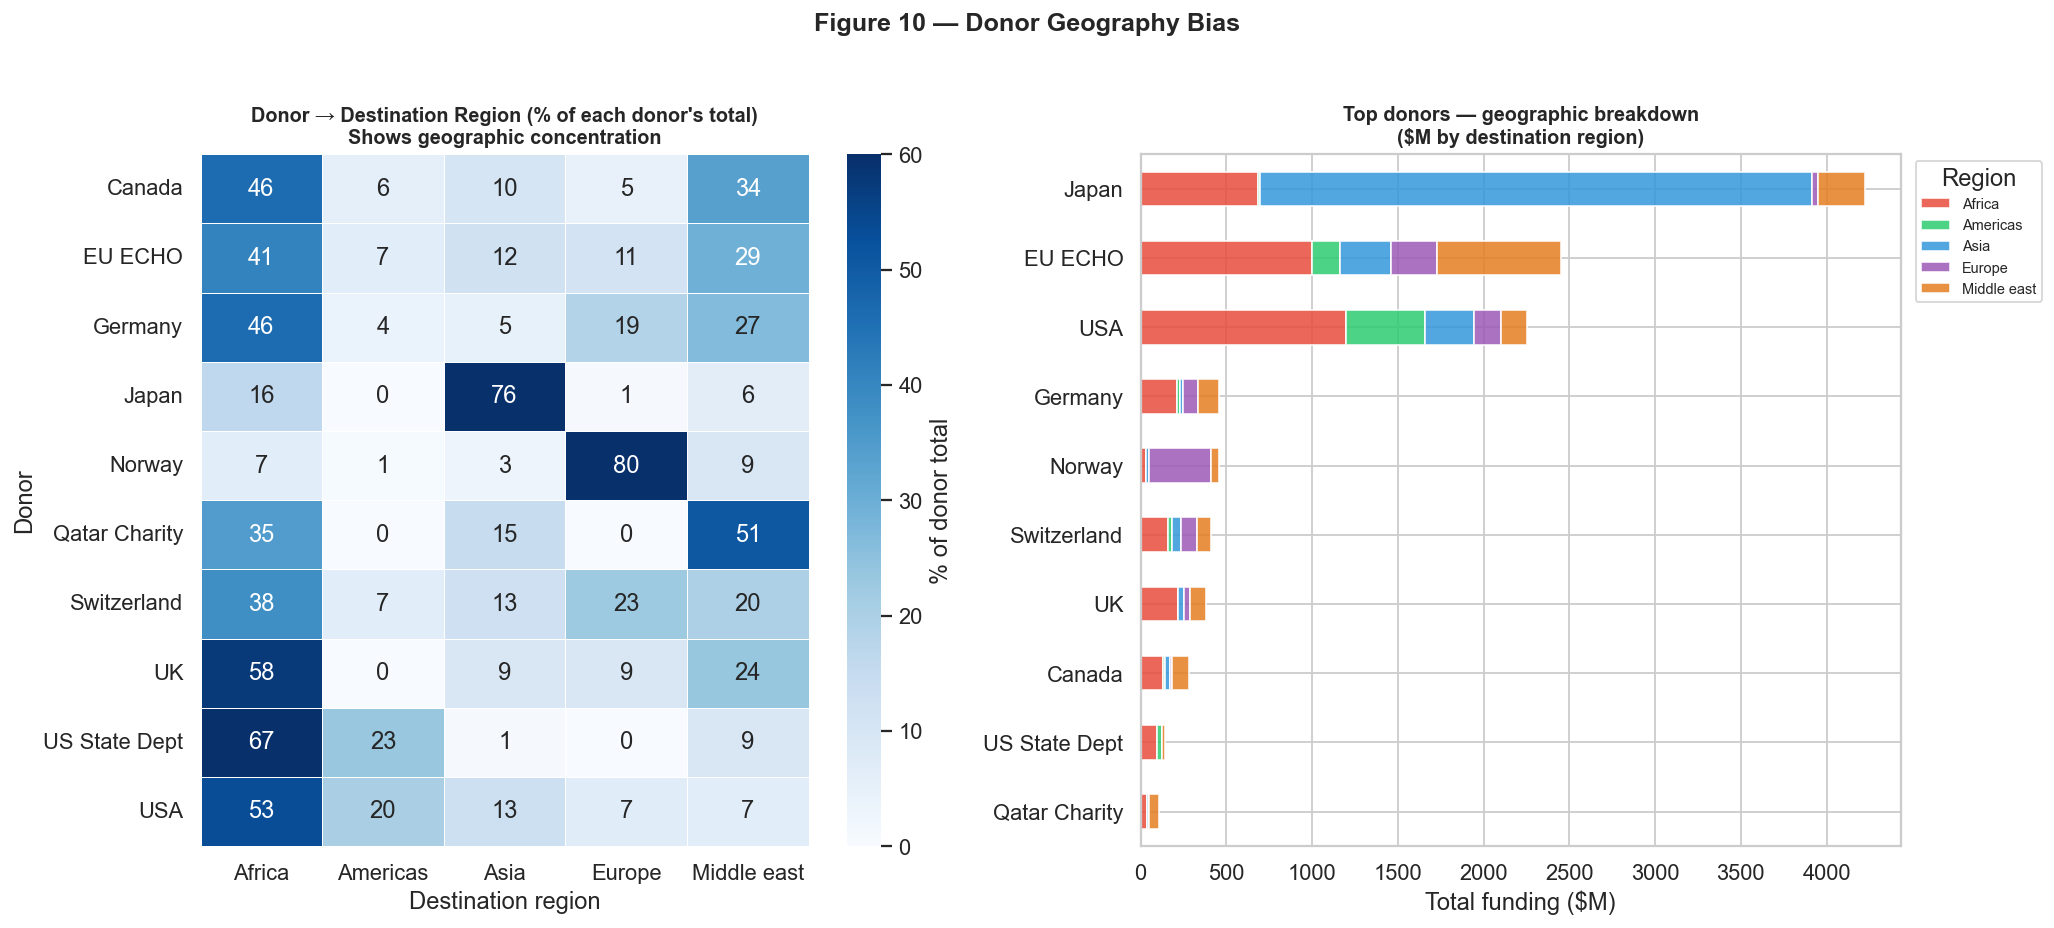

In [12]:
# Use FTS incoming funding to analyse donor concentration
fts_in['amountUSD'] = pd.to_numeric(fts_in['amountUSD'], errors='coerce')
fts_in['budgetYear'] = pd.to_numeric(fts_in['budgetYear'], errors='coerce')

# Top 10 donors by volume
top_donors = fts_in.groupby('srcOrganization')['amountUSD'].sum().nlargest(10)

# Donor → destination country mapping
fts_dest = fts_in[fts_in['srcOrganization'].isin(top_donors.index)].copy()
# Parse destination country from destLocations (ISO3 codes)
fts_dest['dest_iso3'] = fts_dest['destLocations'].astype(str).str.extract(r'([A-Z]{3})')

# Map iso3 → region using our severity-derived region data
iso_region_map = df[['Country_ISO3', 'region']].dropna().drop_duplicates().set_index('Country_ISO3')['region'].to_dict()
fts_dest['dest_region'] = fts_dest['dest_iso3'].map(iso_region_map)

donor_region = (
    fts_dest.dropna(subset=['dest_region'])
            .groupby(['srcOrganization', 'dest_region'])['amountUSD']
            .sum()
            .reset_index()
)
donor_region_pivot = donor_region.pivot(index='srcOrganization', columns='dest_region', values='amountUSD').fillna(0)

# Normalise to % of each donor's total
donor_pct = donor_region_pivot.div(donor_region_pivot.sum(axis=1), axis=0) * 100

# Shorten donor names for readability
def short_donor(d):
    mapping = {
        'Japan, Government of': 'Japan',
        "European Commission's Humanitarian Aid and Civil Protection Department": 'EU ECHO',
        'United States of America, Government of': 'USA',
        'Germany, Government of': 'Germany',
        'Norway, Government of': 'Norway',
        'Switzerland, Government of': 'Switzerland',
        'United Kingdom, Government of': 'UK',
        'Canada, Government of': 'Canada',
        'United States Department of State': 'US State Dept',
        'Qatar Charity': 'Qatar Charity',
    }
    return mapping.get(d, d[:25])

donor_pct.index = [short_donor(d) for d in donor_pct.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap: donor × region distribution
ax = axes[0]
sns.heatmap(donor_pct, cmap='Blues', annot=True, fmt='.0f', linewidths=0.5,
            ax=ax, cbar_kws={'label': '% of donor total'}, vmin=0, vmax=60)
ax.set_title('Donor → Destination Region (% of each donor\'s total)\n'
             'Shows geographic concentration', fontsize=11, fontweight='bold')
ax.set_xlabel('Destination region')
ax.set_ylabel('Donor')

# Absolute donor volumes + regional breakdown
ax2 = axes[1]
region_cols = [c for c in donor_region_pivot.columns]
region_colors = [PALETTE.get(c, '#95a5a6') for c in region_cols]
donor_abs = donor_region_pivot.div(1e6)  # $M
donor_abs.index = [short_donor(d) for d in donor_abs.index]
donor_abs_sorted = donor_abs.loc[donor_abs.sum(axis=1).sort_values().index]
donor_abs_sorted.plot(kind='barh', stacked=True, ax=ax2,
                       color=region_colors, alpha=0.85)
ax2.set_xlabel('Total funding ($M)')
ax2.set_title('Top donors — geographic breakdown\n($M by destination region)', 
              fontsize=11, fontweight='bold')
ax2.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Figure 10 — Donor Geography Bias', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

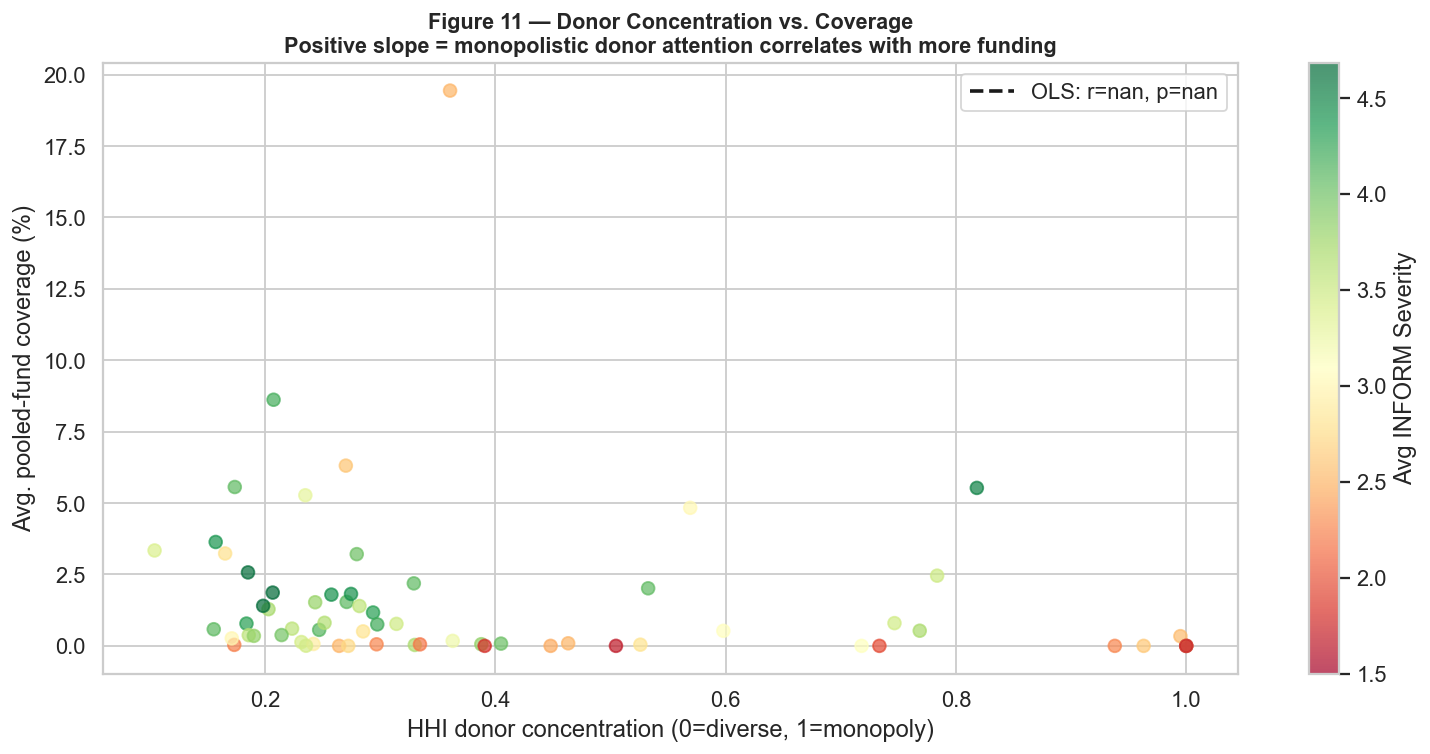

HHI → Coverage: slope=nan, R²=nan, p=nan


In [13]:
# Donor concentration: Herfindahl-Hirschman Index (HHI) per destination country
country_donor = (
    fts_in.dropna(subset=['amountUSD'])
          .assign(dest_iso3=lambda d: d['destLocations'].astype(str).str.extract(r'([A-Z]{3})'))
          .dropna(subset=['dest_iso3'])
          .groupby(['dest_iso3', 'srcOrganization'])['amountUSD']
          .sum()
          .reset_index()
)
country_total = country_donor.groupby('dest_iso3')['amountUSD'].sum()
country_donor['share'] = country_donor['amountUSD'] / country_donor['dest_iso3'].map(country_total)
hhi = country_donor.groupby('dest_iso3')['share'].apply(lambda s: (s**2).sum()).rename('HHI')

hhi_df = hhi.reset_index()
hhi_df['country_name'] = hhi_df['dest_iso3'].map(name_map).fillna(hhi_df['dest_iso3'])
hhi_df = hhi_df.merge(
    df.groupby('Country_ISO3').agg(avg_cov=('coverage', 'mean'), avg_sev=('INFORM Severity Index', 'mean')).reset_index(),
    left_on='dest_iso3', right_on='Country_ISO3', how='left'
)

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    hhi_df['HHI'].dropna(), 
    hhi_df.loc[hhi_df['HHI'].notna(), 'avg_cov'] * 100,
    c=hhi_df.loc[hhi_df['HHI'].notna(), 'avg_sev'],
    cmap='RdYlGn', alpha=0.7, s=50
)
plt.colorbar(scatter, ax=ax, label='Avg INFORM Severity')
m3, b3, r3, p3, _ = stats.linregress(
    hhi_df['HHI'].dropna(),
    hhi_df.loc[hhi_df['HHI'].notna(), 'avg_cov']
)
x_l = np.linspace(0, 1, 100)
ax.plot(x_l, (m3 * x_l + b3) * 100, 'k--', lw=2, label=f'OLS: r={r3:.2f}, p={p3:.3f}')
ax.set_xlabel('HHI donor concentration (0=diverse, 1=monopoly)')
ax.set_ylabel('Avg. pooled-fund coverage (%)')
ax.set_title('Figure 11 — Donor Concentration vs. Coverage\n'
             'Positive slope = monopolistic donor attention correlates with more funding',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'HHI → Coverage: slope={m3:.3f}, R²={r3**2:.3f}, p={p3:.4f}')

---
## 8. Multivariate Bias Test — What Actually Predicts Underfunding?

GBM 5-fold CV R² = 0.266


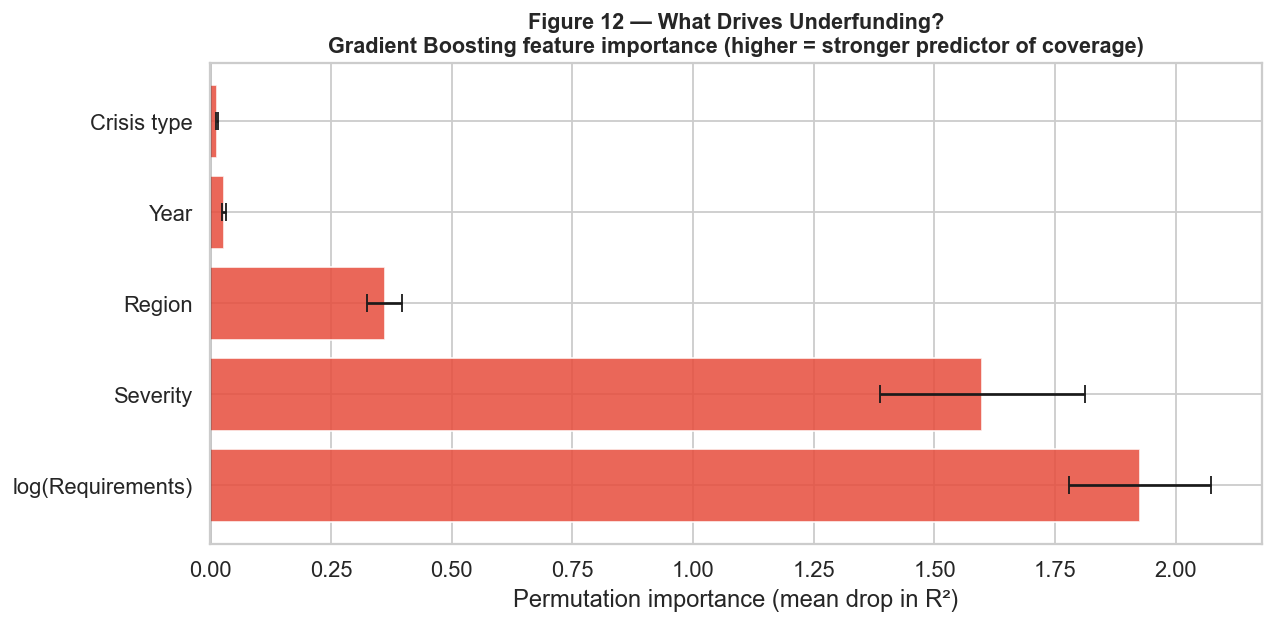


Feature importances:
          feature  importance      std
log(Requirements)    1.925828 0.148055
         Severity    1.598749 0.212477
           Region    0.360971 0.036221
             Year    0.027977 0.003921
      Crisis type    0.014525 0.002246


In [14]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

# Build regression dataset
reg_df = df.dropna(subset=['coverage', 'INFORM Severity Index', 'revisedRequirements']).copy()
reg_df['log_req'] = np.log1p(reg_df['revisedRequirements'])

# Encode categoricals
le_region = LabelEncoder()
le_crisis = LabelEncoder()
reg_df['region_enc'] = le_region.fit_transform(reg_df['region'].fillna('Unknown'))
reg_df['crisis_enc'] = le_crisis.fit_transform(reg_df['crisis_group'].fillna('Unknown'))

features = ['INFORM Severity Index', 'log_req', 'region_enc', 'crisis_enc', 'Year']
X = reg_df[features].values
y = reg_df['coverage'].values

model = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X, y)
cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
print(f'GBM 5-fold CV R² = {cv_r2:.3f}')

# Permutation importance
perm = permutation_importance(model, X, y, n_repeats=20, random_state=42)
imp_df = pd.DataFrame({
    'feature': ['Severity', 'log(Requirements)', 'Region', 'Crisis type', 'Year'],
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_c = ['#e74c3c' if imp > 0.01 else '#95a5a6' for imp in imp_df['importance']]
ax.barh(imp_df['feature'], imp_df['importance'],
        xerr=imp_df['std'], color=bar_c, alpha=0.85, capsize=5)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Permutation importance (mean drop in R²)')
ax.set_title('Figure 12 — What Drives Underfunding?\n'
             'Gradient Boosting feature importance (higher = stronger predictor of coverage)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFeature importances:')
print(imp_df.to_string(index=False))

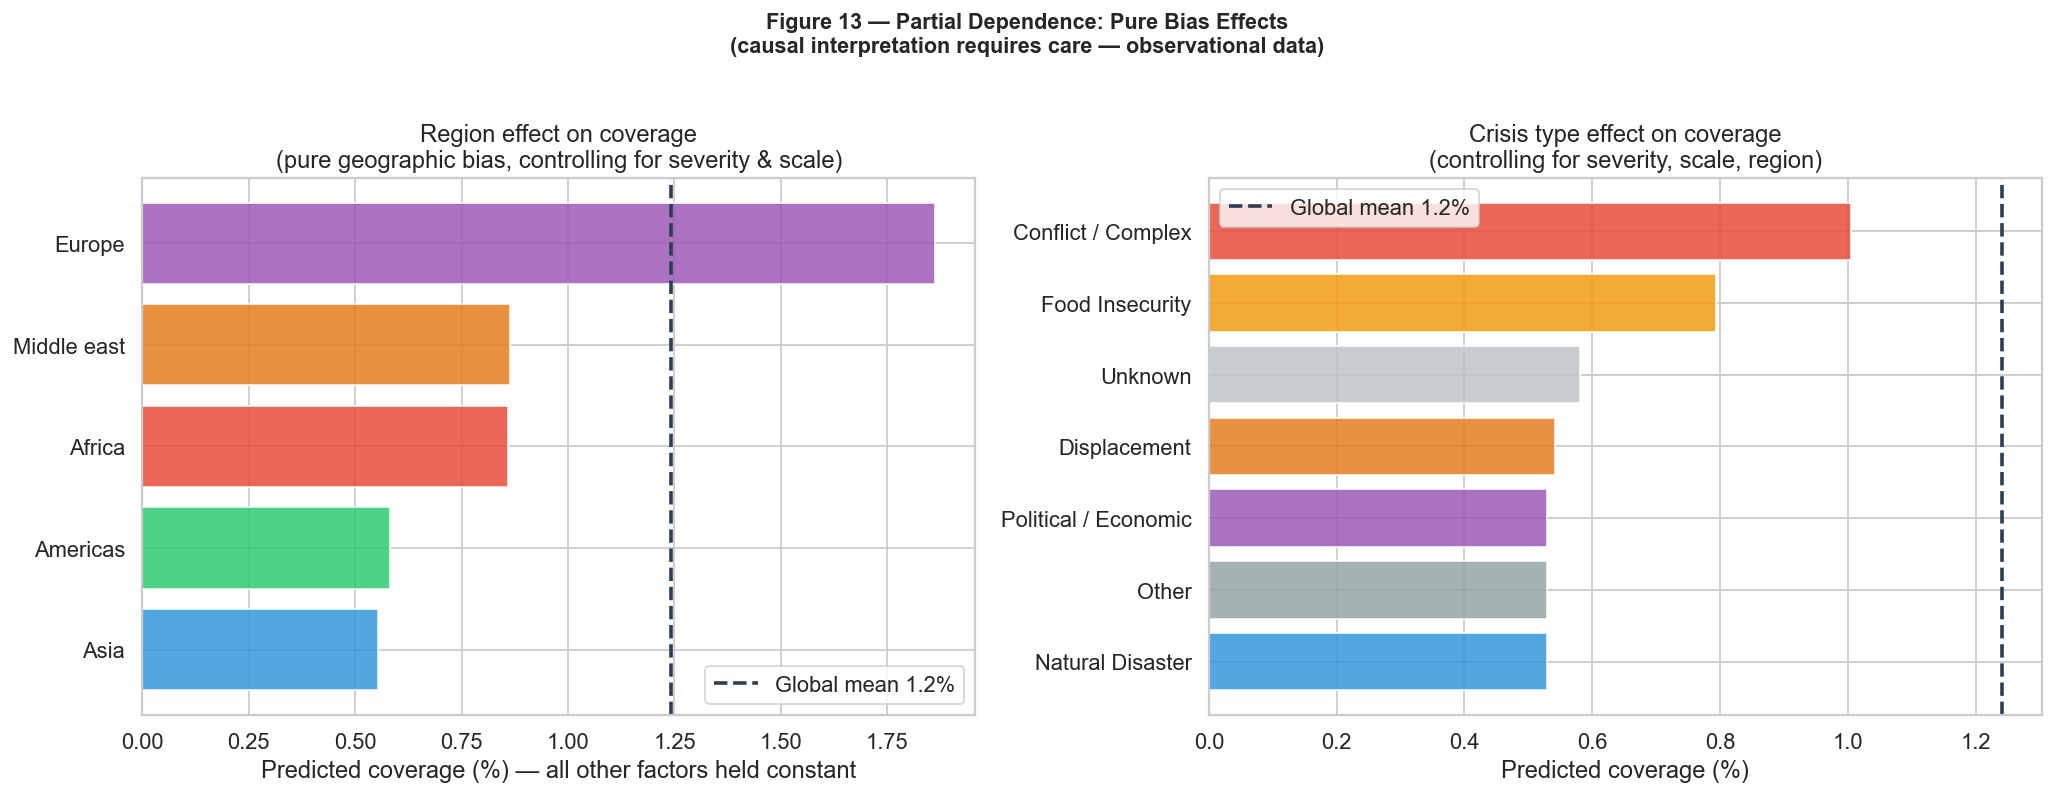

In [15]:
# Partial dependence: show effect of each categorical feature on coverage
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Region partial effect: predict coverage holding other features at median
medians = {f: np.median(X[:, i]) for i, f in enumerate(features)}

def partial_effect(cat_feat_idx, cat_labels, cat_le):
    base = np.array([[medians[f] for f in features]] * len(cat_labels))
    base[:, cat_feat_idx] = list(range(len(cat_labels)))
    preds = model.predict(base)
    return pd.Series(preds, index=cat_le.inverse_transform(list(range(len(cat_labels)))))

# Region
ax = axes[0]
reg_effect = partial_effect(2, le_region.classes_, le_region).sort_values()
bar_colors = [PALETTE.get(r, '#95a5a6') for r in reg_effect.index]
ax.barh(reg_effect.index, reg_effect.values * 100, color=bar_colors, alpha=0.85)
global_mean = df['coverage'].mean() * 100
ax.axvline(global_mean, color='#2c3e50', lw=2, ls='--', label=f'Global mean {global_mean:.1f}%')
ax.set_xlabel('Predicted coverage (%) — all other factors held constant')
ax.set_title('Region effect on coverage\n(pure geographic bias, controlling for severity & scale)')
ax.legend()

# Crisis type
ax2 = axes[1]
crisis_effect = partial_effect(3, le_crisis.classes_, le_crisis).sort_values()
c_colors = [crisis_colors.get(c, '#95a5a6') for c in crisis_effect.index]
ax2.barh(crisis_effect.index, crisis_effect.values * 100, color=c_colors, alpha=0.85)
ax2.axvline(global_mean, color='#2c3e50', lw=2, ls='--', label=f'Global mean {global_mean:.1f}%')
ax2.set_xlabel('Predicted coverage (%)')
ax2.set_title('Crisis type effect on coverage\n(controlling for severity, scale, region)')
ax2.legend()

plt.suptitle('Figure 13 — Partial Dependence: Pure Bias Effects\n'
             '(causal interpretation requires care — observational data)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. The "Forgotten Crises" Quadrant — High Severity, Low Coverage

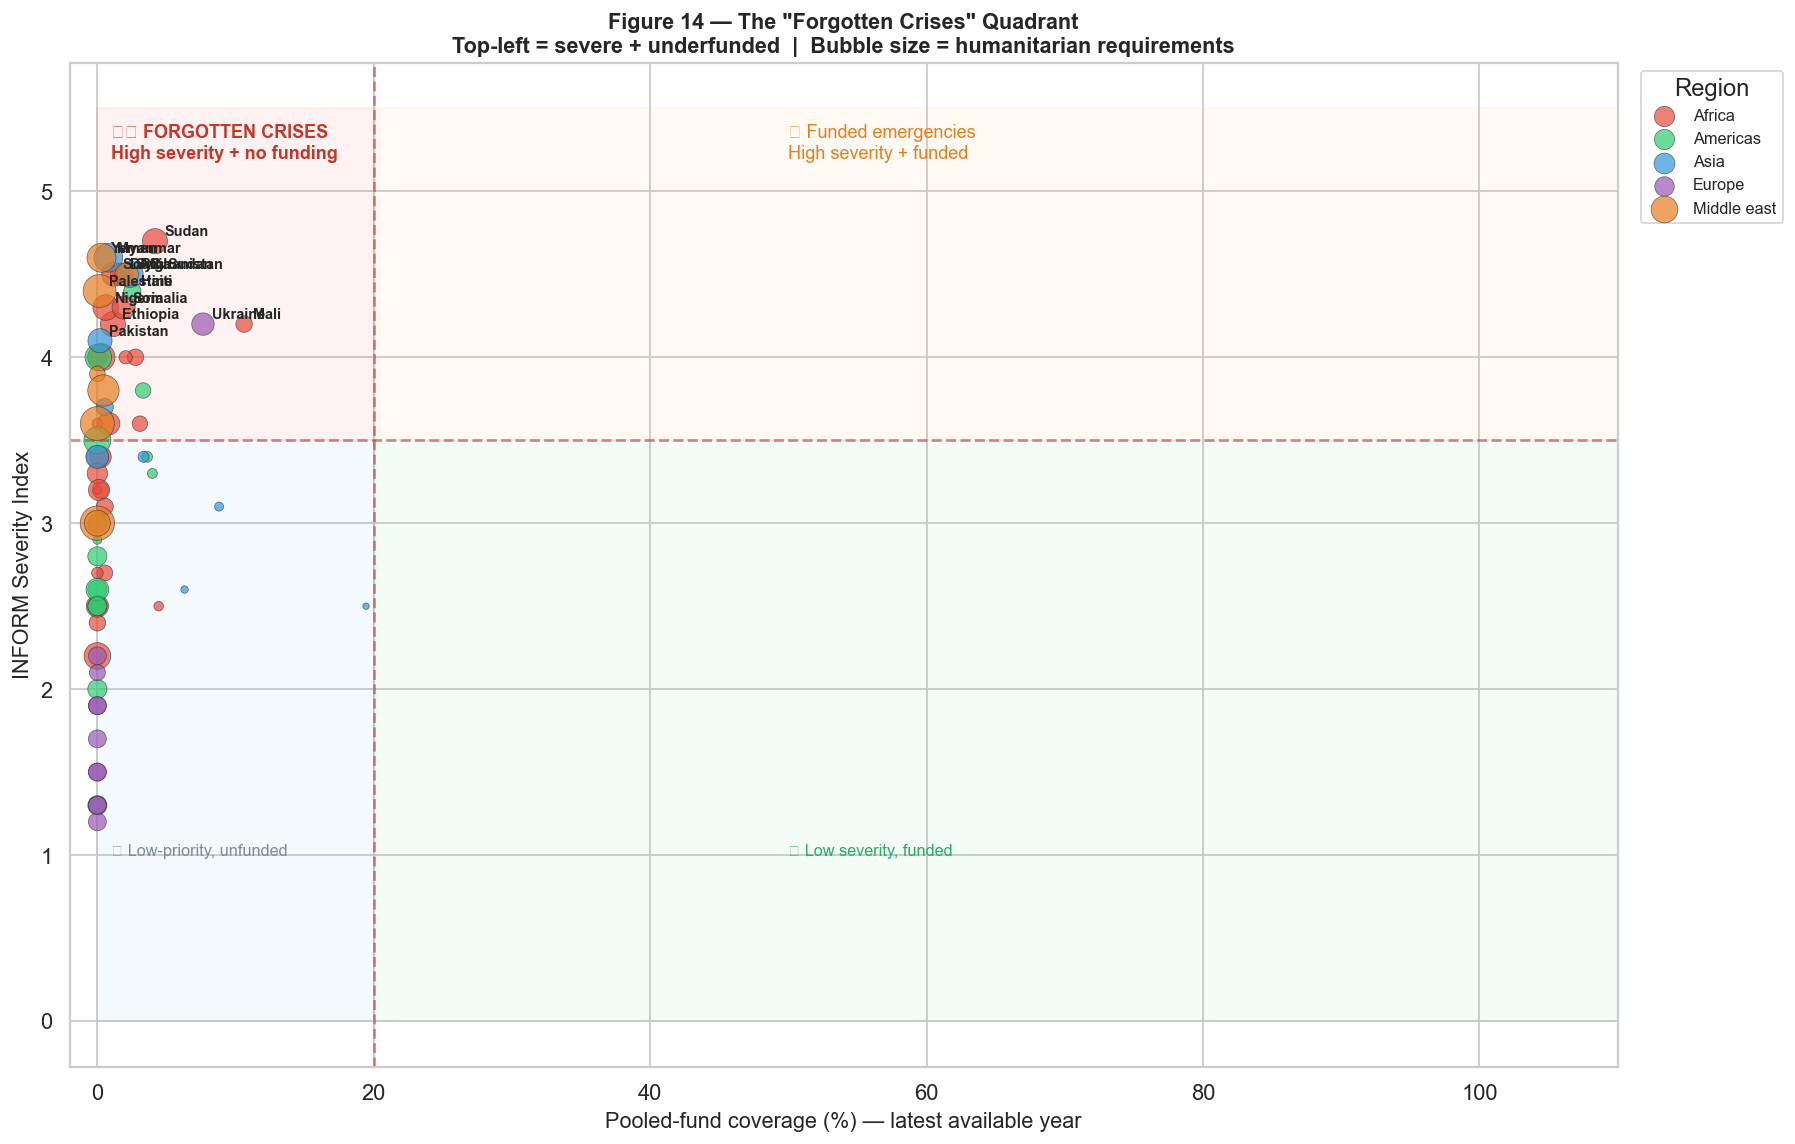


Forgotten crises (sev ≥ 3.5, cov < 20%): 29 countries
country_name  Year  coverage  INFORM Severity Index      region
       Sudan  2025       4.2                    4.7      Africa
       Yemen  2025       0.3                    4.6 Middle east
     Myanmar  2025       0.8                    4.6        Asia
         DRC  2025       1.7                    4.5      Africa
 Afghanistan  2025       2.4                    4.5        Asia
       Syria  2025       2.1                    4.5 Middle east
 South Sudan  2025       1.2                    4.5      Africa
       Haiti  2025       2.5                    4.4    Americas
   Palestine  2025       0.2                    4.4 Middle east
     Nigeria  2025       0.6                    4.3      Africa
     Somalia  2025       1.9                    4.3      Africa
    Ethiopia  2025       1.1                    4.2      Africa
        Mali  2025      10.6                    4.2      Africa
     Ukraine  2025       7.6                    4

In [16]:
# Latest year available per country
latest = df.sort_values('Year').groupby('Country_ISO3').last().reset_index()
latest['country_name'] = latest['Country_ISO3'].map(name_map).fillna(latest['Country_ISO3'])
latest_plot = latest.dropna(subset=['INFORM Severity Index', 'coverage', 'region'])

fig, ax = plt.subplots(figsize=(14, 9))

# Quadrant backgrounds
ax.fill_between([0, 20], [3.5, 3.5], [5.5, 5.5], color='#e74c3c', alpha=0.07)
ax.fill_between([20, 110], [3.5, 3.5], [5.5, 5.5], color='#f39c12', alpha=0.05)
ax.fill_between([0, 20], [0, 0], [3.5, 3.5], color='#3498db', alpha=0.05)
ax.fill_between([20, 110], [0, 0], [3.5, 3.5], color='#2ecc71', alpha=0.05)

for region, grp in latest_plot.groupby('region'):
    ax.scatter(
        grp['coverage'] * 100,
        grp['INFORM Severity Index'],
        s=np.sqrt(grp['revisedRequirements'].clip(1e6) / 1e6) * 3,
        color=PALETTE.get(region, '#95a5a6'),
        alpha=0.7, edgecolors='#333', lw=0.4,
        label=region
    )

# Label the forgotten crises quadrant
forgotten = latest_plot[(latest_plot['coverage'] < 0.20) & (latest_plot['INFORM Severity Index'] >= 3.5)]
for _, row in forgotten.nlargest(15, 'INFORM Severity Index').iterrows():
    ax.annotate(
        row['country_name'],
        (row['coverage'] * 100, row['INFORM Severity Index']),
        xytext=(5, 3), textcoords='offset points',
        fontsize=8, fontweight='bold'
    )

# Quadrant labels
ax.text(1, 5.2, '⚠️ FORGOTTEN CRISES\nHigh severity + no funding', 
        fontsize=10, color='#c0392b', fontweight='bold')
ax.text(50, 5.2, '✓ Funded emergencies\nHigh severity + funded', 
        fontsize=10, color='#e67e22')
ax.text(1, 1.0, '➜ Low-priority, unfunded', fontsize=9, color='#7f8c8d')
ax.text(50, 1.0, '✓ Low severity, funded', fontsize=9, color='#27ae60')

ax.axhline(3.5, color='#c0392b', lw=1.5, ls='--', alpha=0.6)
ax.axvline(20, color='#c0392b', lw=1.5, ls='--', alpha=0.6)
ax.set_xlabel('Pooled-fund coverage (%) — latest available year', fontsize=12)
ax.set_ylabel('INFORM Severity Index', fontsize=12)
ax.set_title('Figure 14 — The "Forgotten Crises" Quadrant\n'
             'Top-left = severe + underfunded  |  Bubble size = humanitarian requirements',
             fontsize=12, fontweight='bold')
ax.set_xlim(-2, 110)
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nForgotten crises (sev ≥ 3.5, cov < 20%): {len(forgotten)} countries')
print(forgotten[['country_name', 'Year', 'coverage', 'INFORM Severity Index', 'region']]
      .sort_values('INFORM Severity Index', ascending=False)
      .assign(coverage=lambda d: (d['coverage'] * 100).round(1))
      .head(20).to_string(index=False))

---
## 10. CERF Geographic Bias — Underfunded Emergencies Window vs. Regions

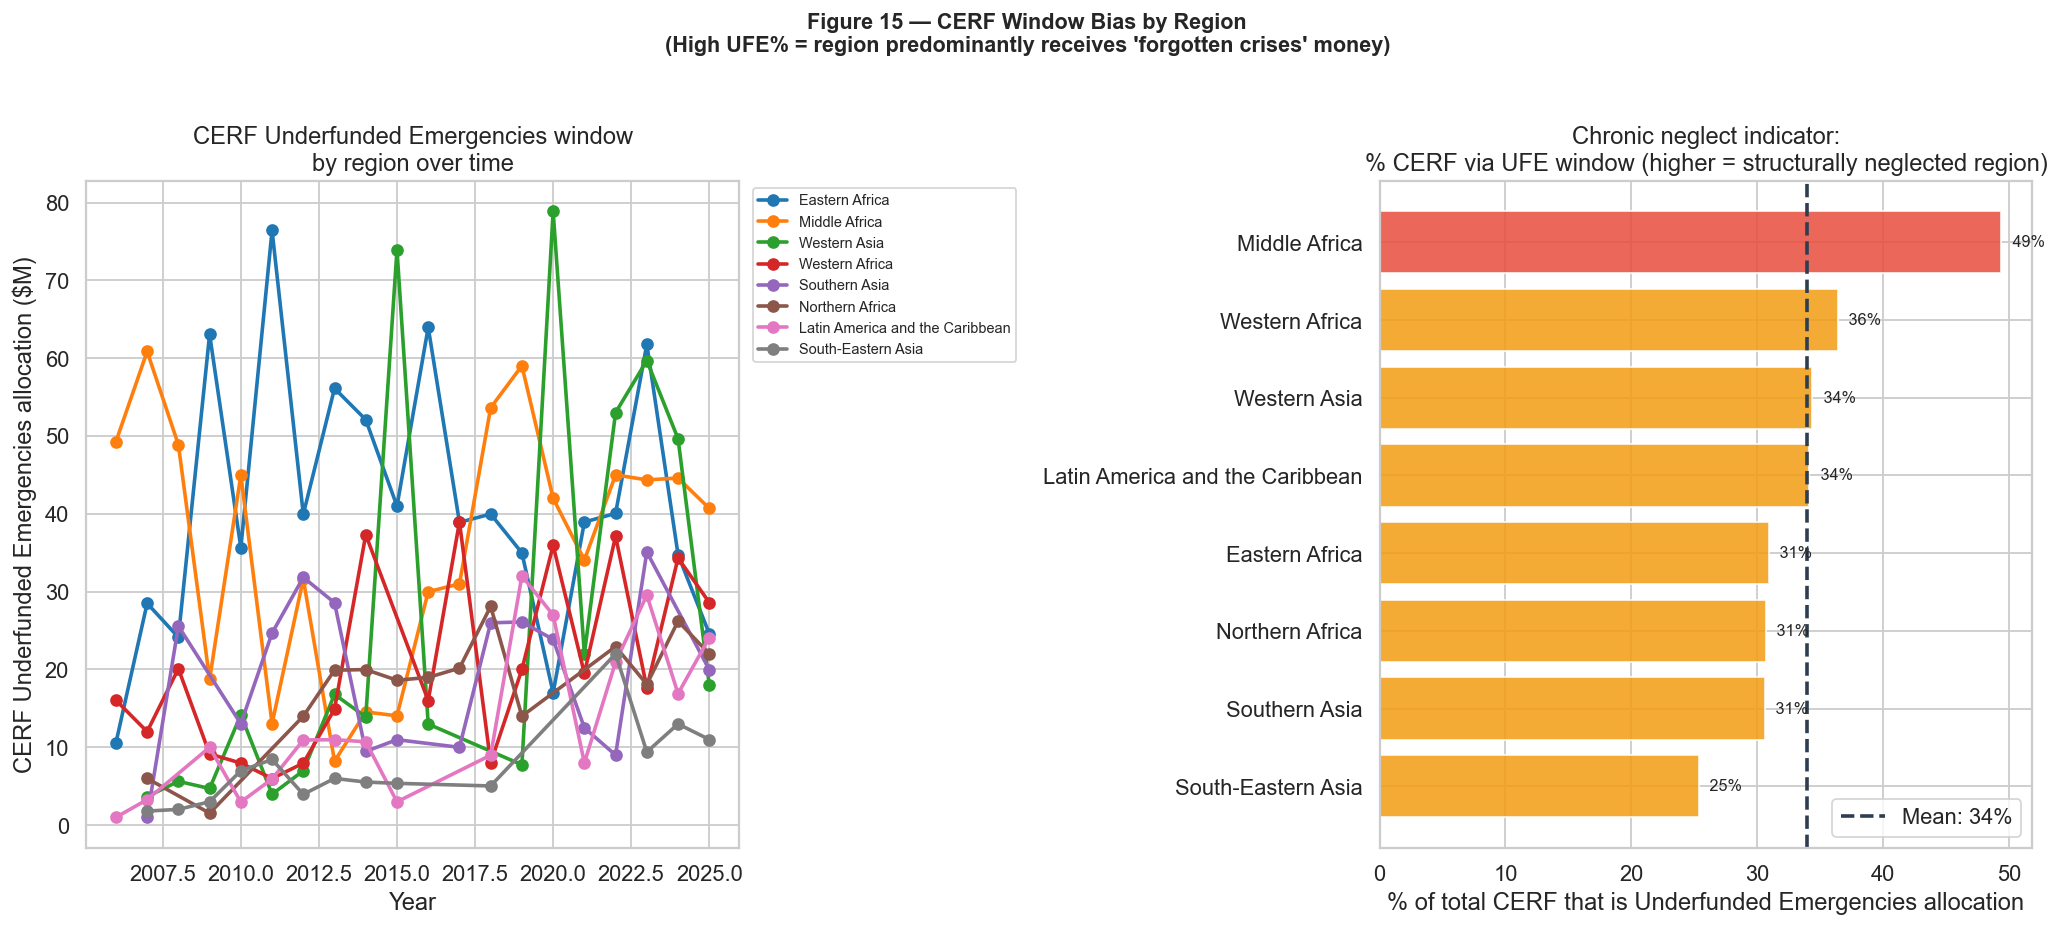

In [17]:
cerf['year'] = pd.to_numeric(cerf['year'], errors='coerce')
cerf_trend = (
    cerf.groupby(['year', 'regionName', 'windowFullName'])['totalAmountApproved']
        .sum().reset_index()
)

# Focus on Underfunded Emergencies window by region over time
ufe = cerf_trend[cerf_trend['windowFullName'] == 'Underfunded Emergencies'].copy()
rr = cerf_trend[cerf_trend['windowFullName'] == 'Rapid Response'].copy()

# Top 8 regions by total CERF
top_regions = cerf.groupby('regionName')['totalAmountApproved'].sum().nlargest(8).index

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# UFE trend by region
ax = axes[0]
region_pal = sns.color_palette('tab10', len(top_regions))
for i, region in enumerate(top_regions):
    rd = ufe[ufe['regionName'] == region].sort_values('year')
    if len(rd) > 0:
        ax.plot(rd['year'], rd['totalAmountApproved'] / 1e6,
                marker='o', lw=2, label=region, color=region_pal[i])
ax.set_xlabel('Year')
ax.set_ylabel('CERF Underfunded Emergencies allocation ($M)')
ax.set_title('CERF Underfunded Emergencies window\nby region over time')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1))

# RR vs UFE ratio by region (does some region rely more on UFE?)
ax2 = axes[1]
ufe_tot = cerf[cerf['windowFullName'] == 'Underfunded Emergencies'].groupby('regionName')['totalAmountApproved'].sum()
rr_tot = cerf[cerf['windowFullName'] == 'Rapid Response'].groupby('regionName')['totalAmountApproved'].sum()
ratio = (ufe_tot / (ufe_tot + rr_tot) * 100).dropna().sort_values()
ratio = ratio[ratio.index.isin(top_regions)]
colors_r = ['#e74c3c' if v > 40 else '#f39c12' if v > 25 else '#2ecc71' for v in ratio]
ax2.barh(ratio.index, ratio.values, color=colors_r, alpha=0.85)
ax2.axvline(ratio.mean(), color='#2c3e50', lw=2, ls='--', label=f'Mean: {ratio.mean():.0f}%')
for i, val in enumerate(ratio.values):
    ax2.text(val + 0.5, i, f' {val:.0f}%', va='center', fontsize=9)
ax2.set_xlabel('% of total CERF that is Underfunded Emergencies allocation')
ax2.set_title('Chronic neglect indicator:\n% CERF via UFE window (higher = structurally neglected region)')
ax2.legend()

plt.suptitle('Figure 15 — CERF Window Bias by Region\n'
             '(High UFE% = region predominantly receives \'forgotten crises\' money)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Summary of Findings

In [18]:
# ── Summary statistics table ───────────────────────────────────────────────
print('=' * 70)
print('BIAS ANALYSIS SUMMARY — Does the UN Discriminate?')
print('=' * 70)

print('\n1. GEOGRAPHIC BIAS')
for _, row in region_stats.iterrows():
    flag = '🔴' if row['med_cov'] < 0.10 else '🟡' if row['med_cov'] < 0.20 else '🟢'
    print(f"   {flag} {row['region']:15s}: median {row['med_cov']*100:5.1f}%  (n={int(row['n'])})")

print('\n2. CRISIS TYPE BIAS')
for _, row in ct_stats.iterrows():
    flag = '🔴' if row['med'] < 0.10 else '🟡' if row['med'] < 0.20 else '🟢'
    print(f"   {flag} {row['crisis_group']:25s}: median {row['med']*100:5.1f}%  (n={int(row['n'])})")

print('\n3. SEVERITY ALIGNMENT')
print(f"   Correlation (r) = {r:.3f}, p = {p:.4f}")
print(f"   → {'Severity positively predicts funding ✓' if m > 0 and p < 0.05 else 'WEAK / REVERSED — severity alone does NOT drive funding ⚠️'}")

print('\n4. SCALE EFFECT')
print(f"   Log-log slope = {m2:.3f}  (1.0 = proportional)")
print(f"   → {'Large crises get proportionally MORE funding' if m2 > 1 else 'Large crises get proportionally LESS per-dollar coverage ⚠️' if m2 < 0.9 else 'Roughly proportional'}")

print('\n5. MOST STRUCTURALLY NEGLECTED CRISES')
worst5 = neglect[neglect['avg_severity'] >= 3.0].nlargest(5, 'pct_years_below20')
for _, row in worst5.iterrows():
    cn = name_map.get(row['Country_ISO3'], row['Country_ISO3'])
    print(f"   🔴 {cn:25s}: {row['pct_years_below20']:.0f}% of years below 20%, avg sev {row['avg_severity']:.1f}")

print('\n6. MOST UNDERFUNDED SECTORS')
for _, row in clust_agg.head(4).iterrows():
    print(f"   🔴 {row['cluster_norm']:25s}: {row['coverage']*100:.1f}% covered")

print('\n7. DONOR CONCENTRATION')
print(f"   HHI → Coverage: slope={m3:.3f}, R²={r3**2:.3f}")
print(f"   → {'Concentrated donors correlate with MORE coverage ⚠️ (dependence risk)' if m3 > 0 and p3 < 0.05 else 'No significant effect'}")

print('\n' + '=' * 70)
print('CAVEAT: All analysis is observational pooled-fund data only.')
print('CERF + CBPF ≠ total aid. Bilateral flows not captured here.')
print('=' * 70)

BIAS ANALYSIS SUMMARY — Does the UN Discriminate?

1. GEOGRAPHIC BIAS
   🔴 Americas       : median   0.0%  (n=81)
   🔴 Europe         : median   0.0%  (n=32)
   🔴 Middle east    : median   0.2%  (n=46)
   🔴 Africa         : median   0.6%  (n=155)
   🔴 Asia           : median   1.0%  (n=32)

2. CRISIS TYPE BIAS
   🔴 Displacement             : median   0.0%  (n=32)
   🔴 Other                    : median   0.1%  (n=8)
   🔴 Natural Disaster         : median   0.2%  (n=13)
   🔴 Unknown                  : median   0.2%  (n=247)
   🔴 Political / Economic     : median   0.2%  (n=1)
   🔴 Food Insecurity          : median   0.9%  (n=1)
   🔴 Conflict / Complex       : median   1.1%  (n=44)

3. SEVERITY ALIGNMENT
   Correlation (r) = 0.310, p = 0.0000
   → Severity positively predicts funding ✓

4. SCALE EFFECT
   Log-log slope = 1.129  (1.0 = proportional)
   → Large crises get proportionally MORE funding

5. MOST STRUCTURALLY NEGLECTED CRISES
   🔴 Afghanistan              : 100% of years below 2